---

# 스프린트미션12 3팀_김명환

- 미션 소개
    - Hugging Face transformers 라이브러리를 사용하여 문서 요약 모델을 구현하는 미션입니다. 데이터 로드 및 전처리부터 요약 모델 실행, 결과 평가까지 전체 파이프라인을 구축해 보세요.

- 사용 데이터셋
    - 먼저 이번 미션에 사용할 데이터 셋을 다운로드 받아주세요. (약 0.4GB)

- 데이터 형식:
    - JSON 파일 형태로 제공되며, 3종류(신문 기사, 사설, 법률)의 문서가 포함되어 있습니다.

- 데이터 구성:
    - 각 문서 타입은 train/test 쌍으로 구성되어 있으며, 전체 데이터를 모두 사용하거나 원하는 문서 종류를 선택하여 학습시키면 됩니다.

- 가이드라인
    - 데이터 로드 및 전처리
        - 문서 데이터를 로드하고, 불필요한 기호나 공백을 제거하는 등 전처리 작업을 수행합니다.
        - 텍스트 길이를 확인하고, 모델 입력에 적합한 형식으로 변환합니다.
    - 모델 선택 및 실행
        - Hugging Face의 transformers 라이브러리를 활용해 문서 요약을 수행합니다.
        - 사전 학습된 모델을 활용하거나 주어진 데이터를 가지고 Fine-tuning을 해 보세요.
    - 모델 평가 및 결과 분석
        - 생성된 요약문과 원본 문서를 비교하여 ROUGE 등의 평가 지표를 사용해 요약 품질을 분석합니다.
        - 테스트 문장에 대한 요약 결과를 출력하여 모델의 성능을 확인합니다.
    - 마크다운 설명
        - 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 마크다운 셀을 통해 간결하게 기록하세요.
        - 코드와 결과를 한눈에 이해할 수 있도록 전체 워크플로우를 체계적으로 정리해 주세요.

---
---

# 한국어 문서 요약 모델 실험 보고서

## 1. 실험 개요

### 1.1. 미션 목표

본 실험은 Hugging Face Transformers 라이브러리를 활용하여 한국어 문서 요약(Text Summarization) 모델을 구축하는 것을 목표로 한다. 데이터 로드 및 전처리부터 모델 파인튜닝(Fine-tuning), 결과 평가까지 전체 파이프라인을 구현하고, 그 과정에서 발생한 문제점과 학습 내용을 기록한다.

### 1.2. 실험 환경 및 제약사항

**주요 제약사항**:
- 에폭(Epoch)당 학습 시간: 약 7시간
- 시간 제약으로 인한 충분한 하이퍼파라미터 실험 불가
- 에폭별 상세 비교 분석의 어려움

**학습 환경**:
- COLAB
- 체크포인트 저장 전략: Best Model (Validation Loss 기준) + Last Model

### 1.3. 사용 모델: KoBART

본 실험에서는 SKT에서 공개한 **KoBART**(Korean BART) 모델을 사용하였다. KoBART는 페이스북(Facebook)의 BART(Bidirectional and Auto-Regressive Transformers) 아키텍처를 한국어 데이터로 사전 학습한 시퀀스-투-시퀀스(Sequence-to-Sequence) 모델이다.

**KoBART의 특징**:
- **인코더-디코더 구조**: 입력 텍스트를 이해하고 요약문을 생성
- **한국어 특화**: 한국어 문법과 어휘에 최적화된 사전 학습
- **다양한 태스크 지원**: 요약, 번역, 생성 등 다양한 NLP 태스크에 활용 가능

## 2. 데이터셋

### 2.1. 데이터셋 구성

본 실험에서는 AI Hub에서 제공하는 문서 요약 데이터셋을 사용하였다. 전체 데이터셋 크기는 약 1.6GB이며, 3종류의 문서 타입으로 구성되어 있다.

| 문서 타입 | 학습 샘플 수 | 파일 크기 | 파일명 |
|---------|------------|----------|--------|
| 신문 기사 (News) | 243,983 | 1.16 GB | `train_original_news.json` |
| 사설/잡지 (Editorial) | 56,760 | 328 MB | `train_original_editorial.json` |
| 법률 문서 (Law) | 24,329 | 86 MB | `train_original_law.json` |
| **합계** | **325,072** | **1.57 GB** | - |

### 2.2. 데이터 타입별 특성

- 신문 기사 (News)
    - 가장 많은 샘플 수를 보유한 문서 타입이다. 다양한 주제와 분야의 뉴스 기사로 구성되어 있다.
- 사설/잡지 (Editorial)
    - 오피니언과 사설 기사로 구성된 데이터셋이다. 논평적이고 주장이 담긴 텍스트가 특징이다.
- 법률 문서 (Law)
    - 판례와 법률 문서로 구성된 데이터셋이다. 전문적이고 형식적인 문체가 특징이다.

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/카테고리분포_원형.png" width="300px"/>
<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/카테고리분포_막대.png" width="300px"/><br/>
<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/원문길이_분포.png" width="300px"/>
<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/요약문길이_분포.png" width="300px"/>


### 2.3. 데이터 전처리

**주요 전처리 과정**:
1. JSON 파일 로드 및 파싱
2. 텍스트 정규화 (불필요한 공백, 특수문자 제거)
3. 토큰화(Tokenization) 및 길이 제한
4. 학습/검증 데이터 분할

실험에서는 검증 데이터로 24,394개의 샘플을 사용하였으며, 최종 평가 시에는 무작위로 선택된 10개의 샘플을 사용하였다.

## 3. 모델 구조 및 학습 설정

### 3.1. KoBART 아키텍처

KoBART는 **트랜스포머(Transformer)** 기반의 인코더-디코더 모델이다. BART는 노이즈 제거 자기인코딩(Denoising Autoencoding) 방식으로 사전 학습되어, 입력 텍스트의 일부를 마스킹하거나 변형한 후 원본을 복원하는 방식으로 언어 이해 능력을 학습한다.

**핵심 구성 요소**:
- **셀프 어텐션(Self-Attention)**: 입력 시퀀스 내 단어 간 관계 학습
- **크로스 어텐션(Cross-Attention)**: 인코더와 디코더 간 정보 전달
- **포지셔널 인코딩(Positional Encoding)**: 단어의 위치 정보 반영

### 3.2. Fine-tuning 전략

사전 학습된 KoBART 모델을 문서 요약 태스크에 맞게 파인튜닝하였다.

**Fine-tuning 프로세스**:

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/Fine-tuning프로세스.png" width="600px"/>

### 3.3. 하이퍼파라미터

본 실험에서 사용한 주요 하이퍼파라미터는 다음과 같다:

| 파라미터 | 값 | 설명 |
|---------|-----|------|
| Learning Rate | 5e-5 (추정) | 학습률 |
| Batch Size | 32 | 배치 크기 |
| Max Length | default | 최대 입력 길이 |
| Epochs | 5 | 총 학습 에폭 수 |
| Optimizer | AdamW | 최적화 알고리즘 |

### 3.4. 학습 시간 및 리소스

**에폭당 학습 시간**: 약 7시간

이는 대규모 언어 모델(LLM) 학습의 일반적인 특징으로, 다음과 같은 시사점이 있다:

$$
\text{총 학습 시간} = \text{에폭 수} \times \text{에폭당 시간} = 5 \times 7 = 35\text{시간}
$$

긴 학습 시간은 다양한 하이퍼파라미터 실험을 제한하는 주요 제약 요인이 되었다.

**학습 진행 타임라인**:

| 에폭 | 누적 시간 | Train Loss | Val Loss | ROUGE-1 |
|-----|----------|-----------|----------|---------|
| 1 | ~7시간 | 0.6927 | 0.5539 | 0.5162 |
| 2 | ~14시간 | 0.4897 | 0.5401 | **0.5341**  |
| 3 | ~21시간 | 0.4428 | **0.5391**  | 0.5264 |
| 4 | ~28시간 | 0.3852 | 0.5541 | 0.5290 |
| 5 | **~35시간** | 0.3485 | 0.5655 | 0.5316 |

- COLAB 세션이 끊어져서 이어서 학습하는데 시간이 더 걸렸다.
    - Last 모델에 이어서 학습 하도록 구성하였으나 에폭당 시간이 오래 걸려 6시간 50분쯤에 세션이 끊긴다면 학습 진행에 매우 큰 차질이 발생할 것이다.
    - 다음 미션에서 시간이 오래 걸리 경우 데이타 분할 순차 학습을 고려할 것이다.

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/mission_12_gpu_power.png" width="600px"/>

## 4. 학습 과정 분석

### 4.1. 에폭별 학습 진행 상황

본 실험에서는 총 **5개의 에폭**에 걸쳐 학습을 진행하였다. 학습 과정에서 발견한 가장 흥미로운 패턴은 **Validation Loss**와 **ROUGE 점수**가 서로 다른 에폭에서 최적값을 기록했다는 점이다.

**에폭별 학습 지표**:

| Epoch | Train Loss | Val Loss | ROUGE-1 | ROUGE-2 | ROUGE-L |
|-------|-----------|----------|---------|---------|---------|
| 1 | 0.6927 | 0.5539 | 0.5162 | 0.2350 | 0.4880 |
| 2 | 0.4897 | 0.5401 | **0.5341**  | **0.2459**  | **0.5023**  |
| 3 | 0.4428 | **0.5391**  | 0.5264 | 0.2433 | 0.4956 |
| 4 | 0.3852 | 0.5541 | 0.5290 | 0.2420 | 0.4965 |
| 5 | 0.3485 | 0.5655 | 0.5316 | 0.2420 | 0.4994 |

 = ROUGE 최고값 (Epoch 2)  
 = Validation Loss 최저값 (Epoch 3)

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/41에폭별학습진행상황.png" width="300px"/>

### 4.2. Validation Loss 추이

Validation Loss는 **Epoch 3**에서 최저값인 **0.5391**을 기록하였다. 일반적으로 모델 학습에서는 Validation Loss가 가장 낮은 시점을 Best Model로 선정한다.

$$
\text{Best Model} = \arg\min_{\theta} \mathcal{L}_{\text{val}}(\theta)
$$

여기서 $\mathcal{L}_{\text{val}}(\theta)$는 검증 데이터에 대한 손실 함수이며, $\theta$는 모델 파라미터이다.

**Loss 추이 분석**:
- Epoch 1 → 2: Val Loss 감소 (0.5539 → 0.5401, **-2.5%**)
- Epoch 2 → 3: Val Loss 미세 감소 (0.5401 → 0.5391, **-0.2%**)
- Epoch 3 → 4: Val Loss 증가 시작 (0.5391 → 0.5541, **+2.8%**)
- Epoch 4 → 5: Val Loss 지속 증가 (0.5541 → 0.5655, **+2.1%**)

Epoch 3 이후 Validation Loss가 지속적으로 증가하는 것은 일반적으로 **과적합(Overfitting)** 징후로 해석된다.

### 4.3. ROUGE 점수 변화

실제 요약 품질을 측정하는 **ROUGE 점수**는 **Epoch 2**에서 최고값을 기록하였다. 이는 매우 중요한 발견으로, Validation Loss와 태스크 특화 평가 지표 간의 불일치를 명확히 보여준다.

**에폭별 ROUGE 점수 상세 비교**:

| Epoch | ROUGE-1 (F1) | ROUGE-2 (F1) | ROUGE-L (F1) | Val Loss | 비고 |
|-------|--------------|--------------|--------------|----------|------|
| 1 | 0.5162 | 0.2350 | 0.4880 | 0.5539 | 초기 |
| 2 | **0.5341**  | **0.2459**  | **0.5023**  | 0.5401 | **ROUGE 최고** |
| 3 | 0.5264 | 0.2433 | 0.4956 | **0.5391**  | **Val Loss 최저** |
| 4 | 0.5290 | 0.2420 | 0.4965 | 0.5541 | - |
| 5 | 0.5316 | 0.2420 | 0.4994 | 0.5655 | Last Model |

**Epoch 2 vs Epoch 3 비교**:

| 지표 | Epoch 2 (ROUGE 최고) | Epoch 3 (Loss 최저) | 차이 |
|-----|---------------------|---------------------|------|
| ROUGE-1 | **0.5341** | 0.5264 | **-0.77%p** |
| ROUGE-2 | **0.2459** | 0.2433 | **-0.26%p** |
| ROUGE-L | **0.5023** | 0.4956 | **-0.67%p** |
| Val Loss | 0.5401 | **0.5391** | -0.19%  |

**핵심 발견**: Validation Loss가 불과 0.19% 감소하는 동안, ROUGE 점수는 오히려 하락했다. 이는 Loss 최소화가 요약 품질 향상으로 이어지지 않음을 보여준다.

**ROUGE 점수 추이 그래프 (개념도)**:

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/43ROUGE점수변화.png" width="600px"/><br/>
<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/mission_12_valid_loss.png" width="300px"/>
<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/mission_12_train_loss.png" width="300px"/><br/>
<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/mission_12_avg_route1.png" width="300px"/>
<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/mission_12_avg_rougeL.png" width="300px"/>

흥미롭게도 Epoch 4-5에서 ROUGE 점수가 다시 소폭 상승하는 패턴을 보였으나, Epoch 2의 최고점에는 미치지 못했다.

### 4.4. Best Model vs Last Model 선정 기준의 차이

본 실험에서는 두 개의 체크포인트만 저장되었다:

**Best Model (Epoch 3)**:
- Validation Loss 기준으로 자동 저장
- Val Loss: **0.5391** (최저)
- ROUGE-1: 0.5264
- 저장 이유: Loss 최소화

**Last Model (Epoch 5)**:
- 마지막 에폭의 체크포인트
- Val Loss: 0.5655 (높음)
- ROUGE-1: 0.5316
- 저장 이유: 최종 체크포인트

**문제점: 최적 모델(Epoch 2) 유실**:
- ROUGE-1: **0.5341** (최고)
- Val Loss: 0.5401
- 상태:  **저장되지 않음**

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/44BestModelvsLastModel선정기준의차이.png" width="600px"/>

이로 인해 **실제 최고 성능 모델(Epoch 2)이 저장되지 않았으며**, 샘플 테스트를 통한 정성적 비교가 불가능했다.

**이상적 결과와의 비교**:

| 모델 | Val Loss | ROUGE-1 | 저장 여부 | 비고 |
|------|----------|---------|---------|------|
| Epoch 2 | 0.5401 | **0.5341**  |  | 실제 최고 성능 |
| Epoch 3 (Best) | **0.5391**  | 0.5264 |  | Loss 기준 선정 |
| Epoch 5 (Last) | 0.5655 | 0.5316 |  | 마지막 체크포인트 |

이는 **손실 함수와 평가 지표의 목표가 항상 일치하지 않는다**는 중요한 교훈을 제공한다.

$$
\mathcal{L}_{\text{val}} \downarrow \not\Rightarrow \text{ROUGE} \uparrow
$$

실제로 Epoch 2 → 3으로 진행하면서 Val Loss는 감소했지만, ROUGE는 오히려 하락했다.

## 5. 평가 결과

### 5.1. 평가 지표 설명

#### 5.1.1. ROUGE 점수란?

**ROUGE**(Recall-Oriented Understudy for Gisting Evaluation)는 자동 요약 시스템의 품질을 평가하는 대표적인 지표이다. 생성된 요약문과 참조 요약문(정답) 간의 n-gram 중복도를 측정한다.

**주요 ROUGE 지표**:

1. **ROUGE-1**: 유니그램(1-gram) 중복도
   $$
   \text{ROUGE-1} = \frac{\sum_{1\text{-gram} \in \text{reference}} \text{Count}_{\text{match}}(1\text{-gram})}{\sum_{1\text{-gram} \in \text{reference}} \text{Count}(1\text{-gram})}
   $$

2. **ROUGE-2**: 바이그램(2-gram) 중복도 - 문장 순서와 문맥 고려
   $$
   \text{ROUGE-2} = \frac{\sum_{2\text{-gram} \in \text{reference}} \text{Count}_{\text{match}}(2\text{-gram})}{\sum_{2\text{-gram} \in \text{reference}} \text{Count}(2\text{-gram})}
   $$

3. **ROUGE-L**: 최장 공통 부분 수열(Longest Common Subsequence) 기반
   $$
   \text{ROUGE-L} = \frac{LCS(\text{reference}, \text{generated})}{\text{length}(\text{reference})}
   $$

| 지표 | 측정 단위 | 주요 평가 내용 |
|------|-----------|----------------|
| ROUGE-1 | Unigram (단어 1개) | 핵심 단어의 포함 여부 (단어 수준 적합성) |
| ROUGE-2 | Bigram (연속된 단어 2개) | 구문 수준 적합성 및 순서의 일치 (더 엄격한 구문 평가) |
| ROUGE-L | LCS (최장 공통 부분 수열) | 문맥적 흐름과 구조적 유사성 (비연속적인 단어 순서 일치) |

#### 5.1.2. 평가 방법론

- **평가 데이터**: 검증 세트에서 무작위 선택된 10개 샘플
- **비교 대상**: Best Model (Epoch 3) vs Last Model (Epoch 5)

### 5.2. Best Model (Epoch 3) 성능

**ROUGE 점수**:
- **ROUGE-1 (F1)**: 0.3485
- **ROUGE-2 (F1)**: 0.0545
- **ROUGE-L (F1)**: 0.3342

**길이 통계**:
- 평균 원문 길이: 254.0 단어
- 평균 생성 요약 길이: 61.7 단어
- 평균 참조 요약 길이: 30.2 단어
- 평균 압축률: 24.3%

### 5.3. Last Model (Epoch 5) 성능

**ROUGE 점수**:
- **ROUGE-1 (F1)**: 0.4602
- **ROUGE-2 (F1)**: 0.0861
- **ROUGE-L (F1)**: 0.4435

**길이 통계**:
- 평균 원문 길이: 254.0 단어
- 평균 생성 요약 길이: 58.5 단어
- 평균 참조 요약 길이: 30.2 단어
- 평균 압축률: 23.0%

### 5.4. 두 모델의 비교 분석

**정량적 비교**:

| 평가 지표 | Best Model (Epoch 3) | Last Model (Epoch 5) | 차이 | 우수 모델 |
|----------|---------------------|---------------------|------|---------|
| ROUGE-1 (F1) | 0.3485 | **0.4602** | +11.7%p | Last  |
| ROUGE-2 (F1) | 0.0545 | **0.0861** | +3.16%p | Last  |
| ROUGE-L (F1) | 0.3342 | **0.4435** | +10.93%p | Last  |
| 평균 요약 길이 | 61.7 단어 | **58.5 단어** | -3.2 단어 | Last  |
| 압축률 | 24.3% | **23.0%** | -1.3%p | Last  |
| Validation Loss | **0.5391**  | 0.5655 | +0.0264 | Best |

**핵심 발견**:

Validation Loss 기준으로 선정된 Best Model(Epoch 3)보다 Last Model(Epoch 5)이 **모든 ROUGE 지표에서 월등히 우수**한 성능을 보였다. 이는 Loss 기준 모델 선정의 한계를 명확히 보여준다.

### 5.5. 정성적 평가 결과

10개 샘플에 대한 직접 확인 결과, **Last Model(Epoch 5)이 Best Model(Epoch 3)보다 실제로 더 나은 요약을 생성**하는 것으로 확인되었다.

**정성적 비교**:

| 특성 | Best Model (Epoch 3) | Last Model (Epoch 5) |
|-----|---------------------|---------------------|
| 요약 품질 |  보통 |  양호 |
| 노이즈 발생 |  심각함 |  경미함 |
| 반복 문제 |  빈번함 |  일부 발생 |
| 정보 정확성 |  일부 왜곡 |  높음 |
| 문장 완결성 |  자주 미완성 |  대체로 양호 |

**종합 분석**:

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/54두모델의비교분석.png" width="600px"/>

## 6. 문제점 및 관찰 사항

### 6.1. 생성 품질 이슈

실험 결과, 생성된 요약문에서 여러 가지 품질 문제가 관찰되었다.

#### 6.1.1. 노이즈 토큰 발생

모델이 의미 없는 토큰을 생성하는 현상이 발생했다.

**발생 예시**:
- "이로써뷰뷰티" (Last Model)
- ".뷰홈뷰티HD비율코스 첫번째인터보조되기도" (Last Model)
- "코스뷰뷰티클래플러스자연65하시는하실해주벗인터찾LG멤버화장" (Best Model)

**원인 분석**:
1. **토크나이저 문제**: 학습 데이터에 포함된 웹 광고나 메타데이터를 잘못 학습
2. **디코딩 전략**: Beam search나 sampling 파라미터 설정 부적절
3. **학습 데이터 품질**: 전처리 과정에서 노이즈 제거 불충분

**소견**: 
좀 더 학습을 진행하면 품질이 개선될 것으로 생각되나, 시간 제약으로 인해 추가 실험을 진행하지 못한 것이 아쉬움으로 남는다.

#### 6.1.2. 문장 반복 현상

동일하거나 유사한 내용이 반복되는 문제가 관찰되었다.

**반복 패턴 예시**:

```
Last Model (Epoch 5):
"회전근개를 구성하는 5개 근육 중 극상근과 이두근이 파열됐다.
회전근개 파열되어 수술은 성공적이었으나 재활이 중요하다고 강조했다.
첫번째 수술은 성공적으로 끝났고..."
```

```
Best Model (Epoch 3):
"수술은 성공적이었지만 재활이 중요하다고 강조하며 수술 후 3-5년 정도 생각하고 있다고 한다.
첫번째 수술은 성공적으로 끝났으나 재활이 가장 중요하다고 강조했다.
두번째 수술은 수술은 3-4번 수술은..."
```

**원인**:
- **Repetition Penalty 미적용**: 생성 시 반복을 제한하는 파라미터 미사용
- **과적합**: 특정 패턴을 과도하게 학습

#### 6.1.3. 요약 길이 과다

생성된 요약문이 참조 요약문보다 약 2배 긴 문제가 발생했다.

**길이 비교**:

| 구분 | 평균 길이 (단어) | 비율 |
|-----|----------------|------|
| 원문 문서 | 254.0 | 100% |
| 참조 요약 | 30.2 | 11.9% |
| 생성 요약 (Last) | 58.5 | 23.0% |
| 생성 요약 (Best) | 61.7 | 24.3% |

**문제점**:
- 참조 요약의 **약 2배** 길이
- 요약의 간결성(conciseness) 부족
- 중복 정보 포함

**원인**:
- `max_length` 파라미터 설정 과다
- 모델이 간결한 요약보다 상세한 설명을 선호하도록 학습됨

### 6.2. 학습 과정의 문제점

#### 6.2.1. 과적합 징후에 대한 재해석

Epoch 3 이후부터 전통적인 과적합(Overfitting) 지표가 나타났다.

**Training Loss vs Validation Loss 추이**:

| Epoch | Train Loss | Val Loss | Gap (Val - Train) |
|-------|-----------|----------|-------------------|
| 1 | 0.6927 | 0.5539 | **-0.1388** |
| 2 | 0.4897 | 0.5401 | **+0.0504** |
| 3 | 0.4428 | 0.5391 | **+0.0963** |
| 4 | 0.3852 | 0.5541 | **+0.1689**  |
| 5 | 0.3485 | 0.5655 | **+0.2170**  |

**전통적 과적합 지표**:
1. **Train Loss 지속 감소**: 0.6927 → 0.3485 (약 -50%)
2. **Val Loss 증가 전환**: Epoch 3 이후 상승 (0.5391 → 0.5655)
3. **Gap 확대**: Train-Val 격차가 Epoch 5에서 0.2170으로 최대

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/621과적합징후Epoch3이후.png" width="600px"/>

**그러나 실제 성능은?**

흥미롭게도 Val Loss가 증가하는 Epoch 4-5에서도 ROUGE 점수는 소폭 회복되는 경향을 보였다:
- Epoch 3 → 4: ROUGE-1 증가 (0.5264 → 0.5290, +0.26%p)
- Epoch 4 → 5: ROUGE-1 증가 (0.5290 → 0.5316, +0.26%p)

**정성적 평가 결과**:
직접 생성된 요약문을 확인한 결과, **Last Model(Epoch 5)이 Best Model(Epoch 3)보다 실제로 더 나은 요약을 생성**하는 것으로 판단되었다.

**재해석**:
전통적인 Loss 지표만으로는 과적합으로 보이나, 실제 태스크 성능(ROUGE)과 정성적 평가에서는 오히려 개선되는 양상을 보였다. 이는 **평가 지표만으로는 생성형 모델의 실제 성능을 정확히 파악하기 어렵다**는 점을 시사한다.

#### 6.2.2. 평가 지표와 손실함수의 불일치

가장 중요한 발견은 **Validation Loss 최저점**과 **ROUGE 최고점**, 그리고 **정성적 평가 결과**가 모두 다른 에폭에서 나타났다는 것이다.

**비교 요약**:

| 평가 기준 | 최고 에폭 | 수치 | 실제 의미 |
|----------|---------|------|---------|
| Validation Loss | Epoch 3 | 0.5391 | 손실 함수 최소 |
| ROUGE-1 (학습 중) | Epoch 2 | 0.5341 | 자동 평가 최고 |
| ROUGE-1 (샘플 평가) | Epoch 5 | 0.4602 | 실제 생성 최고 |
| 정성적 평가 | Epoch 5 | - | 사람이 판단한 최고 |

**핵심 교훈**:

```
생성형 모델의 경우는 정량적 평가 지표만으로는 부족하며,
정성적인 평가를 통해 실제 생성 품질을 판단해야 한다.
```

따라서:
1. 모든 에폭의 체크포인트를 저장하고
2. 다양한 샘플에 대해 정성적 평가를 수행하거나
3. 대량의 샘플에 대한 평가를 통해 검증이 필요하다

## 7. 실험을 통해 배운 점

### 7.1. Best Model 선정 기준에 대한 고찰

이번 실험의 가장 큰 교훈은 **생성형 모델의 Best Model 선정 기준**에 관한 것이다.

**기존 접근 방식**:
- Validation Loss 최저 = Best Model

**문제점**:
1. Validation Loss와 실제 태스크 성능(ROUGE)의 불일치
2. Epoch 3 모델은 Loss는 낮지만 Epoch 2보다 ROUGE가 낮음
3. 정성적 평가에서는 Epoch 5가 Epoch 3보다 우수함

**개선된 접근 방식**:

| 평가 단계 | 방법 | 목적 |
|----------|------|------|
| 1단계 | 모든 에폭 저장 | 사후 분석 가능 |
| 2단계 | 자동 평가 지표 (ROUGE) | 정량적 성능 측정 |
| 3단계 | 정성적 평가 (샘플 확인) | 실제 생성 품질 확인 |
| 4단계 | 최종 모델 선정 | 종합적 판단 |

**생성형 모델의 특수성**:

생성형 모델(Generative Model)의 경우, 분류(Classification)나 회귀(Regression) 모델과 달리:
- Loss 함수가 실제 생성 품질을 직접 반영하지 못함
- 자동 평가 지표(ROUGE, BLEU)도 한계가 있음
- **최종적으로는 사람의 판단(정성적 평가)이 가장 중요함**

### 7.2. 학습 시간 최적화의 중요성

**시간 제약의 영향**:
- 에폭당 7시간 → 5 에폭 = 35시간
- 다양한 하이퍼파라미터 실험 불가
- 에폭별 상세 비교 어려움

**시간 효율성의 중요성**:

$$
\text{실험 가능 횟수} = \frac{\text{가용 시간}}{\text{학습 시간}} = \frac{T_{\text{total}}}{T_{\text{epoch}} \times N_{\text{epoch}}}
$$

에폭당 시간이 길수록 실험 횟수가 제한되어 최적 설정 발견이 어려워진다.

**학습 중 평가의 비효율성**:
- 학습 + 평가 동시 진행 → 시간 약 2배 소요
- 에폭당 7시간의 상당 부분이 평가에 사용됨

**효율적 접근**:
1. 학습 시에는 평가 생략 → 학습 속도 증가
2. 모든 체크포인트 저장
3. 학습 완료 후 별도로 평가 수행

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/12/72학습시간최적화의중요성.png" width="300px"/>

### 7.3. 체크포인트 저장 전략의 중요성

**실제 발생한 문제**:
- Epoch 2 모델 유실
- 최고 ROUGE 점수(0.5341)를 기록한 모델 분석 불가
- Best/Last 모델만으로는 제한적인 비교만 가능

**핵심 메시지**:

> "대용량 모델을 학습할 때는 Best와 Last만 저장할 것이 아니라,  
> **모든 에폭 또는 주요 에폭을 저장**하여 사후 분석을 가능하게 해야 한다."

특히 에폭당 학습 시간이 긴 경우, **체크포인트 저장은 일종의 보험**이다.

## 8. 결론

### 8.1. 실험 결과 요약

본 실험을 통해 KoBART 기반 한국어 문서 요약 모델을 성공적으로 구축하고 평가하였다.

**주요 성과**:
1.  325,072개의 대규모 한국어 데이터로 Fine-tuning 완료
2.  ROUGE-1 최고 점수 0.5341 달성 (Epoch 2, 학습 중 평가)
3.  3가지 문서 타입(뉴스, 사설, 법률)에 대한 통합 모델 구축
4.  정량적/정성적 평가를 통한 종합적 성능 분석

**핵심 발견**:

1. **Validation Loss ≠ ROUGE ≠ 정성적 품질**
   - Epoch 3: Val Loss 최저 (0.5391)
   - Epoch 2: ROUGE 최고 (0.5341, 학습 중)
   - Epoch 5: 정성적 평가 최고 + 샘플 ROUGE 최고 (0.4602)

2. **과적합의 재해석**
   - Loss 지표상으로는 과적합처럼 보임
   - 하지만 ROUGE는 소폭 회복
   - 정성적 평가에서는 오히려 개선
   - **생성형 모델은 정성적 평가가 필수**

3. **체크포인트 저장의 중요성**
   - 최고 성능 모델(Epoch 2) 유실
   - 모든 에폭 저장이 필요함을 확인

### 8.2. 한계점

**1. 시간 제약**:
- 에폭당 7시간 → 총 35시간 학습
- 충분한 하이퍼파라미터 실험 불가
- 더 많은 에폭 학습 시도 어려움

**2. 체크포인트 저장 전략 실패**:
- 모든 에폭을 저장하고 정성적 평가를 했어야 함
- Epoch 2 모델 유실로 인한 분석 제한

**3. 생성 품질 문제**:
- 노이즈 토큰 발생
- 문장 반복 현상
- 요약 길이 과다 (참조의 약 2배)
- 추가 학습으로 개선 가능할 것으로 예상

**4. 평가 범위 제한**:
- 10개 샘플만 평가 (전체 24,394개 중)
- 시간 제약으로 제한적 샘플링
- 더 많은 샘플 평가와 정성적 평가 필요
- 문서 타입별 성능 차이 미분석

**5. 모델 선정 기준**:
- Validation Loss 기준으로 Best Model 선정
- **생성형 모델은 정성적 검토가 필수적**
- ROUGE 지표는 참고 자료로만 활용

## 8.3. 최종 결론

본 실험을 통해 얻은 가장 중요한 교훈은 다음과 같다:

> **생성형 모델의 성능은 자동 평가 지표만으로 판단하기 어려우며, 실제 생성 결과에 대한 정성적 검증이 함께 이루어져야 한다.**

특히:
- Validation Loss는 모델 수렴의 지표일 뿐, 생성 품질을 보장하지 않음
- ROUGE 등 자동 평가 지표도 실제 품질과 괴리가 있을 수 있음
- **대규모 자동 평가 + 대표 샘플의 정성적 검증**을 병행해야 함
- 본 실험은 10개 샘플만 평가했으므로, 더 많은 샘플로 검증이 필요함

따라서 생성형 모델 학습 시:
1. **모든 체크포인트를 저장**하고
2. **다양한 자동 평가 지표로 1차 선별**하며
3. **충분한 샘플(최소 100개 이상)에 대한 정성적 평가**를 수행하거나
4. **Human evaluation 전까지는 결론을 유보**하는 것이 바람직하다


---
---

In [133]:
!pip install -q rouge-score

In [134]:
import importlib
from urllib.request import urlretrieve

urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_utils.py", "helper_utils.py")
import helper_utils as hu
from helper_utils import *

urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
import importlib
import helper_c0z0c_dev as helper

helper = importlib.reload(helper)
from helper_c0z0c_dev import *

hu = importlib.reload(hu)
from helper_utils import *


🌐 https://c0z0c.github.io/jupyter_hangul
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\homepage\스프린트미션\스프린트미션_작업중
helper_utils.py loaded


In [135]:

# 기본 라이브러리

# --- Scikit-learn: 데이터 전처리, 모델, 평가 ---
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import (
    fetch_california_housing, load_iris, make_moons, make_circles,
    load_breast_cancer, load_wine
)
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.metrics import average_precision_score

# --- 기타 라이브러리 ---
from PIL import Image
from PIL import ImageFilter
from PIL import ImageDraw
import albumentations as A
import IPython.display
#from tqdm import tqdm
from tqdm.notebook import tqdm

# --- PyTorch: 딥러닝 관련 ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import argparse
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as TF
from torch.nn import CrossEntropyLoss
from collections import OrderedDict
from datasets import DatasetDict
from torch.utils.data import DataLoader
from torch.optim import AdamW
from datasets import load_dataset
from transformers import AutoTokenizer

# --- 기타 ---
import re
import os
import sys
import json
import math
import random
import yaml
import shutil
import pandas as pd
import numpy as np
import zipfile
from typing import Union, List
from pathlib import Path

import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import seaborn as sns
from datetime import datetime
from datetime import timezone, timedelta
import pytz
__kst = pytz.timezone('Asia/Seoul')

# GPU 설정
__device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
__device_cpu = torch.device('cpu')

  # 재현 가능한 결과를 위해
np.random.seed(42)
torch.manual_seed(42)
if __device == 'cuda':
    torch.cuda.manual_seed_all(42)

logger = logging.getLogger(__name__)
#logger = logging.getLogger()
#logger.setLevel(logging.DEBUG)
logger.setLevel(logging.INFO)
logger.info(f"라이브러리 로드 완료 사용장치:{__device}")


2025-10-24 17:42:51 [I] 라이브러리 로드 완료 사용장치:cpu


In [136]:
RUN_PROCESS={}
RUN_PROCESS['로직테스트']=False
#RUN_PROCESS['USE_WANDB']=True
RUN_PROCESS['USE_WANDB']=False
RUN_PROCESS['원본데이터로드']=True
RUN_PROCESS['전처리데이터다운로드']=True
RUN_PROCESS['전처리데이터로드']=True
RUN_PROCESS['전처리데이터로드정보']=True
#RUN_PROCESS['데이터셋10']=True
RUN_PROCESS['데이터셋10']=False
RUN_PROCESS['테스트_kobart-base-v1']=False
RUN_PROCESS['학습_정보']=False

#RUN_PROCESS['학습']=True
RUN_PROCESS['학습']=False

RUN_PROCESS['평가']=True
#RUN_PROCESS['평가']=False



# >프로그램< 원본 데이타 로드

In [137]:
if RUN_PROCESS['원본데이터로드']:
    summarization_path = r'D:\dataset\summarization.zip'
    unzip_summarization_path = r'summarization_path.zip.unzip'
    if not Path(unzip_summarization_path).exists():
        unzip_summarization_path = unzip([summarization_path], remove_zip=False)
    else:
        logger.debug(f"이미 압축해제된 폴더가 존재합니다.: {unzip_summarization_path}")
    logger.info(unzip_summarization_path[0])

2025-10-24 17:42:52 [I] D:\dataset\summarization.zip.unzip


이미 압축 해제됨: D:\dataset\summarization.zip.unzip


In [138]:
if RUN_PROCESS['원본데이터로드']:
    jsonfiles = [
        r'D:\dataset\summarization.zip.unzip\summarization\train_original_editorial.json',
        r'D:\dataset\summarization.zip.unzip\summarization\train_original_law.json',
        r'D:\dataset\summarization.zip.unzip\summarization\train_original_news.json',
        r'D:\dataset\summarization.zip.unzip\summarization\valid_original_editorial.json',
        r'D:\dataset\summarization.zip.unzip\summarization\valid_original_law.json',
        r'D:\dataset\summarization.zip.unzip\summarization\valid_original_news.json',
    ]
    for jsonfile in jsonfiles:
        is_exist = os.path.exists(jsonfile)
        size = os.path.getsize(jsonfile) if is_exist else 0
        logger.info(f"JSON파일: {is_exist} ({size}) {jsonfile}")

2025-10-24 17:42:52 [I] JSON파일: True (328441544) D:\dataset\summarization.zip.unzip\summarization\train_original_editorial.json
2025-10-24 17:42:52 [I] JSON파일: True (86422962) D:\dataset\summarization.zip.unzip\summarization\train_original_law.json
2025-10-24 17:42:52 [I] JSON파일: True (1162588030) D:\dataset\summarization.zip.unzip\summarization\train_original_news.json
2025-10-24 17:42:52 [I] JSON파일: True (37050938) D:\dataset\summarization.zip.unzip\summarization\valid_original_editorial.json
2025-10-24 17:42:52 [I] JSON파일: True (8923073) D:\dataset\summarization.zip.unzip\summarization\valid_original_law.json
2025-10-24 17:42:52 [I] JSON파일: True (146765156) D:\dataset\summarization.zip.unzip\summarization\valid_original_news.json


In [139]:

if RUN_PROCESS['원본데이터로드']:
    for jsonfile in jsonfiles:
        is_exist = os.path.exists(jsonfile)
        size = os.path.getsize(jsonfile) if is_exist else 0
        with open(jsonfile, 'r', encoding='utf-8') as f:
            data = json.load(f)
            logger.info(f"JSON파일: {is_exist} ({size}) {jsonfile}")
            print_json_tree(data, max_depth=2)


2025-10-24 17:42:56 [I] JSON파일: True (328441544) D:\dataset\summarization.zip.unzip\summarization\train_original_editorial.json


|-- name(str): 사설/잡지 문서 프로젝트
|-- delivery_date(str): 2020-12-23 15:00:19
|-- documents
    |-- [list] (56760 items)
        |-- [0]
            |-- id(str): 100062073
            |-- category(str): 오피니언
            |-- media_type(str): online
            |-- media_sub_type(str): 경제지
            |-- media_name(str): 매일경제
            |-- size(str): medium
            |-- char_count(str): 1153
            |-- publish_date(str): 2011-09-01 00:03:01
            |-- title(str): [사설] 기부문화 확산 은근히 강조한 李대통령
            |-- text
            |-- annotator_id(int): 3924
            |-- document_quality_scores
            |-- extractive
            |-- abstractive
        |-- ... (56758 items omitted)
        |-- [56759]
            |-- id(str): 351048754
            |-- category(str): 종합
            |-- media_type(str): online
            |-- media_sub_type(str): 경제지
            |-- media_name(str): 이투데이
            |-- size(str): medium
            |-- char_count(str): 1407
            |-- publish

2025-10-24 17:42:57 [I] JSON파일: True (86422962) D:\dataset\summarization.zip.unzip\summarization\train_original_law.json


|-- name(str): 법률문서 프로젝트
|-- delivery_date(str): 2020-12-23 17:23:13
|-- documents
    |-- [list] (24329 items)
        |-- [0]
            |-- id(str): 100004
            |-- category(str): 일반행정
            |-- size(str): small
            |-- char_count(int): 377
            |-- publish_date(str): 19841226
            |-- title(str): 부당노동행위구제재심판정취소
            |-- text
            |-- annotator_id(int): 3783
            |-- document_quality_scores
            |-- extractive
            |-- abstractive
        |-- ... (24327 items omitted)
        |-- [24328]
            |-- id(str): 71828
            |-- category(str): 민사
            |-- size(str): small
            |-- char_count(int): 241
            |-- publish_date(str): 19581209
            |-- title(str): 강제집행이의등청구사건
            |-- text
            |-- annotator_id(int): 3785
            |-- document_quality_scores
            |-- extractive
            |-- abstractive


2025-10-24 17:43:14 [I] JSON파일: True (1162588030) D:\dataset\summarization.zip.unzip\summarization\train_original_news.json


|-- name(str): 문서요약 프로젝트
|-- delivery_date(str): 2020-12-23 12:01:15
|-- documents
    |-- [list] (243983 items)
        |-- [0]
            |-- id(str): 290741778
            |-- category(str): 종합
            |-- media_type(str): online
            |-- media_sub_type(str): 지역지
            |-- media_name(str): 광양신문
            |-- size(str): small
            |-- char_count(str): 927
            |-- publish_date(str): 2018-01-05 18:54:55
            |-- title(str): 논 타작물 재배, 2월 말까지 신청하세요
            |-- text
            |-- annotator_id(int): 11
            |-- document_quality_scores
            |-- extractive
            |-- abstractive
        |-- ... (243981 items omitted)
        |-- [243982]
            |-- id(str): 368479496
            |-- category(str): 종합
            |-- media_type(str): online
            |-- media_sub_type(str): 지역지
            |-- media_name(str): 중도일보
            |-- size(str): medium
            |-- char_count(str): 1178
            |-- publish_date(str)

2025-10-24 17:43:15 [I] JSON파일: True (37050938) D:\dataset\summarization.zip.unzip\summarization\valid_original_editorial.json
2025-10-24 17:43:15 [I] JSON파일: True (8923073) D:\dataset\summarization.zip.unzip\summarization\valid_original_law.json


|-- name(str): 사설/잡지 문서 프로젝트
|-- delivery_date(str): 2020-12-23 15:00:19
|-- documents
    |-- [list] (7008 items)
        |-- [0]
            |-- id(str): 365247698
            |-- category(str): 종합
            |-- media_type(str): online
            |-- media_sub_type(str): 중앙지
            |-- media_name(str): 한국일보
            |-- size(str): medium
            |-- char_count(str): 1171
            |-- publish_date(str): 2019-10-31 04:40:00
            |-- title(str): [사설] 이해찬 대표 ‘조국 사태’ 사과, 과감한 인적 쇄신으로 이어져야
            |-- text
            |-- annotator_id(int): 4750
            |-- document_quality_scores
            |-- extractive
            |-- abstractive
        |-- ... (7006 items omitted)
        |-- [7007]
            |-- id(str): 99988644
            |-- category(str): 증권
            |-- media_type(str): online
            |-- media_sub_type(str): 경제지
            |-- media_name(str): 매일경제
            |-- size(str): medium
            |-- char_count(str): 1167
            |-

2025-10-24 17:43:17 [I] JSON파일: True (146765156) D:\dataset\summarization.zip.unzip\summarization\valid_original_news.json


|-- name(str): 문서요약 프로젝트
|-- delivery_date(str): 2020-12-23 12:01:15
|-- documents
    |-- [list] (30122 items)
        |-- [0]
            |-- id(str): 340626877
            |-- category(str): 정치
            |-- media_type(str): online
            |-- media_sub_type(str): 경제지
            |-- media_name(str): 한국경제
            |-- size(str): medium
            |-- char_count(str): 1111
            |-- publish_date(str): 2019-04-08 17:43:00
            |-- title(str): 文대통령 "5G는 4차산업혁명 시대의 고속도로"
            |-- text
            |-- annotator_id(int): 4209
            |-- document_quality_scores
            |-- extractive
            |-- abstractive
        |-- ... (30120 items omitted)
        |-- [30121]
            |-- id(str): 350861693
            |-- category(str): 경제
            |-- media_type(str): online
            |-- media_sub_type(str): 경제지
            |-- media_name(str): 헤럴드경제
            |-- size(str): small
            |-- char_count(str): 778
            |-- publish_date(

# >프로그램< 전처리 및 dataset 저장

### `clean_text` 함수: 뉴스 도메인 특화 전처리 내용

| **번호** | **전처리 항목**           | **설명**                                                                                     | **정규식**                                                                 |
|----------|---------------------------|---------------------------------------------------------------------------------------------|----------------------------------------------------------------------------|
| 1        | 기자 정보 제거            | `[서울=홍길동 기자]`, `[부산 김철수 기자]`와 같은 기자 정보를 제거                           | `\[[^\]]*기자\]`                                                          |
| 2        | 사진/영상 캡션 제거       | `<사진>`, `(사진)`, `<영상>`, `(영상)`과 같은 사진 및 영상 관련 캡션을 제거                   | `<사진[^>]*>`<br>`\(사진[^\)]*\)`<br>`<영상[^>]*>`<br>`\(영상[^\)]*\)`    |
| 3        | 저작권 문구 제거          | `ⓒ`, `©`와 같은 저작권 표시 및 관련 문구를 제거                                              | `ⓒ\s*[\w가-힣]+`<br>`©\s*[\w가-힣]+`<br>`무단전재.*금지`<br>`무단.*배포.*금지` |
| 4        | 관련기사/더보기 제거      | `▶ 관련기사`, `☞ 관련기사`, `▶ 더보기`와 같은 네비게이션 문구를 제거                         | `▶\s*관련기사`<br>`▶\s*더보기`<br>`☞\s*관련기사`                          |
| 5        | 이메일 수집 거부 문구 제거 | `이메일 무단수집 거부`와 같은 이메일 수집 거부 문구를 제거                                   | `이메일.*무단수집.*거부`                                                  |
| 6        | 기자 이메일 주소 제거     | `example@domain.com`과 같은 기자 이메일 주소를 제거                                           | `[\w\.-]+@[\w\.-]+\.\w+`                                                  |
| 7        | 불필요한 텍스트 제거      | `속보`, `기자 주`, `광고`와 같은 불필요한 텍스트를 제거                                       | `(속보|기자 주|광고)`                                                     |
| 8        | HTML 태그 제거            | `<태그>` 형식의 HTML 태그를 제거                                                              | `<[^>]+>`                                                                 |
| 9        | URL 제거                  | `http://example.com`, `www.example.com`과 같은 URL을 제거                                     | `https?://\S+`<br>`www\.\S+`                                              |
| 10       | 특수 문자 제거            | 한국어, 영문, 숫자, 점(`.`)을 제외한 모든 특수 문자를 제거                                     | `[^가-힣a-zA-Z0-9.\s]`                                                    |
| 11       | 연속된 공백 처리          | 연속된 공백을 하나로 치환하고, 텍스트 앞뒤의 공백을 제거                                       | ` +` → `(하나의 공백)`                                                    |


In [140]:
# 도메인 용어 사전
DOMAIN_TERMS = {"KT&G", "ExiPrep™96 Lite",
                "M&A", "R&D", "C++",
                "㎍/㎥", "㎡", "℃", "b/d",
                "%P"
                }


In [141]:
def clean_text(text: str, domain_terms: set = None) -> str:
    """
    신문 기사 텍스트 전처리 함수

    주요 기능:
    1. 도메인 용어 보호:
        - 도메인 용어 사전에 등록된 단어를 원형 그대로 유지.
        - 대소문자 구분 없이 매칭.
    2. 숫자 사이의 특수 문자 보호:
        - 숫자 사이의 점(.)과 중점(·)을 유지.
    3. 도메인 특화 전처리:
        - 기자 정보, 사진/영상 캡션, 저작권 문구, 관련기사/더보기 등 불필요한 텍스트 제거.
    4. 일반 인터넷 텍스트 전처리:
        - HTML 태그, URL 제거.
        - 한국어, 영문, 숫자, 점(.)을 제외한 모든 특수 문자 제거.
        - 연속된 공백/줄바꿈 처리.
        - 텍스트 앞뒤 공백 제거.

    Args:
        text (str): 원본 텍스트.
        domain_terms (set): 유지할 도메인 용어 사전 (예: {"M&A", "R&D"}).

    Returns:
        str: 전처리된 텍스트.
    """
    if domain_terms is None:
        domain_terms = set()

    # 플레이스홀더 딕셔너리 (도메인 용어 보호를 위한 임시 치환)
    placeholders = {}
    placeholder_counter = 0

    # ========== 1. 도메인 용어 보호 (대소문자 무시) ==========
    # 도메인 용어를 플레이스홀더로 치환하여 원형 보호
    sorted_terms = sorted(domain_terms, key=len, reverse=True)

    for term in sorted(sorted_terms, key=len, reverse=True):  # 긴 단어 우선 처리
        pattern = re.escape(term)  # 특수 문자 이스케이프
        matches = list(re.finditer(pattern, text, flags=re.IGNORECASE))
        for match in reversed(matches):  # 뒤에서부터 치환 (인덱스 보존)
            placeholder = f"__DOMAIN_TERM_{placeholder_counter}__"
            placeholders[placeholder] = match.group(0)  # 원본 대소문자 유지
            text = text[:match.start()] + placeholder + text[match.end():]
            placeholder_counter += 1

    # ========== 2. 숫자 사이의 특수 문자 보호 ==========
    # 숫자 사이의 점(.)과 중점(·)을 각각 플레이스홀더로 치환
    text = re.sub(r'(?<=\d)\.(?=\d)', '__DOT__', text)  # 예: 3.14 → 3__DOT__14
    text = re.sub(r'(?<=\d)·(?=\d)', '__MIDDOT__', text)  # 예: 4·3 → 4__MIDDOT__3

    # ========== 3. 도메인 특화 전처리 ==========
    # 기자 정보 제거
    text = re.sub(r'\[[^\]]*기자\]', ' ', text)
    # 사진/영상 캡션 제거
    text = re.sub(r'<사진[^>]*>', ' ', text)
    text = re.sub(r'\(사진[^\)]*\)', ' ', text)
    text = re.sub(r'<영상[^>]*>', ' ', text)
    text = re.sub(r'\(영상[^\)]*\)', ' ', text)
    # 저작권 문구 제거
    text = re.sub(r'ⓒ\s*[\w가-힣]+', ' ', text)
    text = re.sub(r'©\s*[\w가-힣]+', ' ', text)
    text = re.sub(r'무단전재.*금지', ' ', text)
    text = re.sub(r'무단.*배포.*금지', ' ', text)
    # 관련기사/더보기 등 네비게이션 문구 제거
    text = re.sub(r'▶\s*관련기사', ' ', text)
    text = re.sub(r'▶\s*더보기', ' ', text)
    text = re.sub(r'☞\s*관련기사', ' ', text)
    # 이메일 수집 거부 문구 제거
    text = re.sub(r'이메일.*무단수집.*거부', ' ', text)
    # 기자 이메일 주소 제거
    text = re.sub(r'[\w\.-]+@[\w\.-]+\.\w+', ' ', text)
    # "속보", "기자 주", "광고" 등의 불필요한 텍스트 제거
    text = re.sub(r'(속보|기자 주|광고)', ' ', text)

    # ========== 4. 일반 인터넷 텍스트 전처리 ==========
    # HTML 태그 제거
    text = re.sub(r'<[^>]+>', ' ', text)
    # URL 제거
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'www\.\S+', ' ', text)
    # 연속된 점 제거
    text = re.sub(r'\.{2,}', ' ', text)

    # 특수 문자 제거 (한글, 영문, 숫자, 공백, 마이너스, 플레이스홀더만 유지)
    text = re.sub(r'[^가-힣a-zA-Z0-9\s_.\-·]', ' ', text)

    # ========== 5. 플레이스홀더 복원 ==========
    # 숫자 사이의 특수 문자 복원
    text = text.replace('__DOT__', '.')
    text = text.replace('__MIDDOT__', '·')
    # 도메인 용어 복원
    for placeholder, original in placeholders.items():
        text = text.replace(placeholder, original)

    # ========== 6. 공백 정규화 ==========
    # 연속된 공백을 하나로 치환하고, 앞뒤 공백 제거
    text = re.sub(r' +', ' ', text)
    return text.strip()

if RUN_PROCESS['원본데이터로드']:
    sample_texts = [
        "이 회사는 M&A를 통해 성장했습니다.",
        "m&a 계약과 R&d 투자, c++ 언어와 4·3 사건",
        "토지 ㎡당 540만원, 어패류 85℃ 이상 가열, 86만b/d(1일당 배럴)",
    ]

    for text in sample_texts:
        cleaned = clean_text(text, domain_terms=DOMAIN_TERMS)
        logger.info(f"원본: {text}")
        logger.info(f"전처리: {cleaned}\n")

2025-10-24 17:43:17 [I] 원본: 이 회사는 M&A를 통해 성장했습니다.
2025-10-24 17:43:17 [I] 전처리: 이 회사는 M&A를 통해 성장했습니다.

2025-10-24 17:43:17 [I] 원본: m&a 계약과 R&d 투자, c++ 언어와 4·3 사건
2025-10-24 17:43:17 [I] 전처리: m&a 계약과 R&d 투자 c++ 언어와 4·3 사건

2025-10-24 17:43:17 [I] 원본: 토지 ㎡당 540만원, 어패류 85℃ 이상 가열, 86만b/d(1일당 배럴)
2025-10-24 17:43:17 [I] 전처리: 토지 ㎡당 540만원 어패류 85℃ 이상 가열 86만b/d 1일당 배럴



In [142]:
def convert_news_to_jsonl(news_filepath, jsonl_filepath, ignore = True):
    if not os.path.exists(news_filepath):
        logger.error(f"뉴스파일이 존재하지 않습니다.: {news_filepath}")
        return

    Path(jsonl_filepath).parent.mkdir(parents=True, exist_ok=True)

    logger.info(f"JSON파일: {os.path.exists(news_filepath)} {news_filepath}")
    if(os.path.exists(jsonl_filepath)) and ignore:
        os.remove(jsonl_filepath)

    with open(news_filepath, 'r', encoding='utf-8') as f_in, open(jsonl_filepath, 'w', encoding='utf-8') as f_out:
        js = json.load(f_in)
        jdocuments = js['documents']
        #print_json_tree(js, max_depth=5)
        logger.info(f"문서개수: {len(jdocuments)}")

        pbar = tqdm(jdocuments, total=len(jdocuments), desc="변환중")
        for doc in pbar:
            texts_list = []

            add_dataset={
            "id": doc['id'],
            "document": "",
            "summary": "",
            "metadata": {
                "category": doc['category'],
                "media_sub_type": doc['media_sub_type'],
                "media_name": doc['media_name'],
                "publish_date": doc['publish_date'],
                "title": doc['title'],
                "char_count": 0,
                "summary_count": 0,
                }
            }
            texts_list.append(doc['title'])

            for txts in doc['text']:
                for text in txts:
                    index = text['index']
                    sentence = text['sentence']
                    texts_list.append(sentence)

            summary = ' '.join(doc['abstractive'])
            if len(summary) > 5:
                summary = clean_text(summary)
                if len(summary) > 5:
                    add_dataset['summary'] = summary
                    document = clean_text(' '.join(texts_list))
                    add_dataset['document'] = document
                    add_dataset['metadata']['char_count'] = len(add_dataset['document'])
                    add_dataset['metadata']['summary_count'] = len(add_dataset['summary'])
                    json_line = json.dumps(add_dataset, ensure_ascii=False)
                    f_out.write(json_line + '\n')
                else:
                    logger.debug(f"0 요약문이 너무 짧음 (5자 이하): {doc['id']}")
                    logger.debug(f"0 summary: [{summary}]")
            else:
                logger.debug(f"1 요약문이 너무 짧음 (5자 이하): {doc['id']}")
                logger.debug(f"1 summary: [{summary}]")

        logger.info(f"변환 완료: {news_filepath} -> {jsonl_filepath}")

if RUN_PROCESS['원본데이터로드']:
    newsfiles = [
        {'src': r'D:\dataset\summarization.zip.unzip\summarization\train_original_news.json',
        'dest': r'D:\dataset\summarization.zip.unzip_dataset\default\train.jsonl'
        },
        {'src': r'D:\dataset\summarization.zip.unzip\summarization\valid_original_news.json',
        'dest': r'D:\dataset\summarization.zip.unzip_dataset\default\validation.jsonl'
        },
    ]

# >설명<
- 원본 데이타를 로딩하였다.
- 신문 요약을 위한 jsonl을 만들었다.
    - documnet = title + text list
    - cummary = abstractive
- document 전처리 적용
    - 일반적인 인터넷 text 전처리
    - 도메인 특화 전처리
        [홍길동 기자], 저작권, 이미지, ...
    - 특이사항
        전처리시 문자 삭제(x) -> 공백으로 치환 -> 연속된 공백을 공백하나로 치환 (문맥유지)

- Hugging Face LLM에 친화적인 폴더 구조와 파일 구조로 저장하였다.

In [143]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# 데이터 준비
def prepare_dataframe(jsonl_path: str) -> pd.DataFrame:
    """
    JSONL 파일에서 뉴스 데이터를 읽어 데이터프레임으로 변환.

    Args:
        jsonl_path (str): JSONL 파일 경로.

    Returns:
        pd.DataFrame: 변환된 데이터프레임 (category, char_count, summary_count 필드 포함).
    """
    # 파일 존재 여부 확인
    jsonl_file = Path(jsonl_path)
    if not jsonl_file.exists():
        raise FileNotFoundError(f"파일이 존재하지 않습니다: {jsonl_path}")

    # JSONL 파일 읽기
    data = pd.read_json(jsonl_file, lines=True, encoding="utf-8")

    # 필요한 필드 추출
    df = pd.DataFrame({
        "category": data["metadata"].apply(lambda x: x["category"]),
        "char_count": data["metadata"].apply(lambda x: x["char_count"]),
        "summary_count": data["metadata"].apply(lambda x: x["summary_count"]),
    })

    return df

# 시각화 함수
def visualize_data(df):
    """
    뉴스 데이터 시각화.

    Args:
        df (pd.DataFrame): 데이터프레임.
    """

    # 카테고리 분포 원형 그래프
    plt.figure(figsize=(8, 8))
    category_counts = df['category'].value_counts()
    category_counts.plot.pie(
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette("viridis", len(category_counts)),
        wedgeprops={'edgecolor': 'black'}
    )
    plt.title("카테고리 분포 (원형 그래프)")
    plt.ylabel("")  # y축 라벨 제거
    plt.tight_layout()
    plt.savefig("mission_11_category_distribution_pie.png")
    plt.show()

    # 카테고리 분포
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x="category", palette="viridis")
    plt.title("카테고리 분포")
    plt.xlabel("카테고리")
    plt.ylabel("개수")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("mission_11_category_distribution.png")
    plt.show()

    # 요약문 길이 대비 원문 길이 히스토그램
    plt.figure(figsize=(10, 6))
    sns.histplot(df["char_count"] / df["summary_count"], bins=30, kde=True, color="blue")
    plt.title("요약문 길이 대비 원문 길이 비율")
    plt.xlabel("원문 길이 / 요약문 길이")
    plt.ylabel("빈도")
    plt.tight_layout()
    plt.savefig("mission_11_length_ratio_histogram.png")
    plt.show()

    # 요약문 길이 분포
    plt.figure(figsize=(10, 6))
    sns.histplot(df["summary_count"], bins=30, kde=True, color="green")
    plt.title("요약문 길이 분포")
    plt.xlabel("요약문 길이")
    plt.ylabel("빈도")
    plt.tight_layout()
    plt.savefig("mission_11_summary_length_distribution.png")
    plt.show()

    # 원문 길이 분포
    plt.figure(figsize=(10, 6))
    sns.histplot(df["char_count"], bins=30, kde=True, color="orange")
    plt.title("원문 길이 분포")
    plt.xlabel("원문 길이")
    plt.ylabel("빈도")
    plt.tight_layout()
    plt.savefig("mission_11_document_length_distribution.png")
    plt.show()

if RUN_PROCESS['원본데이터로드']:
    news_data = [
        {
            "id": "1",
            "document": "원문 텍스트 예시",
            "summary": "요약문 예시",
            "metadata": {
                "category": "뉴스",
                "media_sub_type": "일반",
                "media_name": "언론사",
                "publish_date": "2025-10-21",
                "title": "기사 제목",
                "char_count": 500,
                "summary_count": 100,
            },
        },
        {
            "id": "2",
            "document": "다른 원문 텍스트 예시",
            "summary": "다른 요약문 예시",
            "metadata": {
                "category": "사설",
                "media_sub_type": "칼럼",
                "media_name": "언론사",
                "publish_date": "2025-10-20",
                "title": "다른 기사 제목",
                "char_count": 800,
                "summary_count": 150,
            },
        },
    ]
    # 데이터프레임 준비
    df_train = prepare_dataframe(newsfiles[0]['dest'])
    df_validation = prepare_dataframe(newsfiles[1]['dest'])


In [144]:
if RUN_PROCESS['원본데이터로드']:
    df_train['category'].value_counts().head_att(50)
    print("-" * 80)
    df_validation['category'].value_counts().head_att(50)

인덱스           count   
index            count   
종합             177555  
경제             23938   
사회             17649   
정치             16389   
스포츠           5174    
IT,과학          1931    
교육/입시/NIE    1190    
부동산           74      
보건/의료        55      
기업             17      
북한/한반도정세  5       
선거             2       
--------------------------------------------------------------------------------
인덱스   count  
index    count  
종합     13666  
IT,과학  10997  
경제     3403   
사회     1503   
스포츠   392    
정치     161    


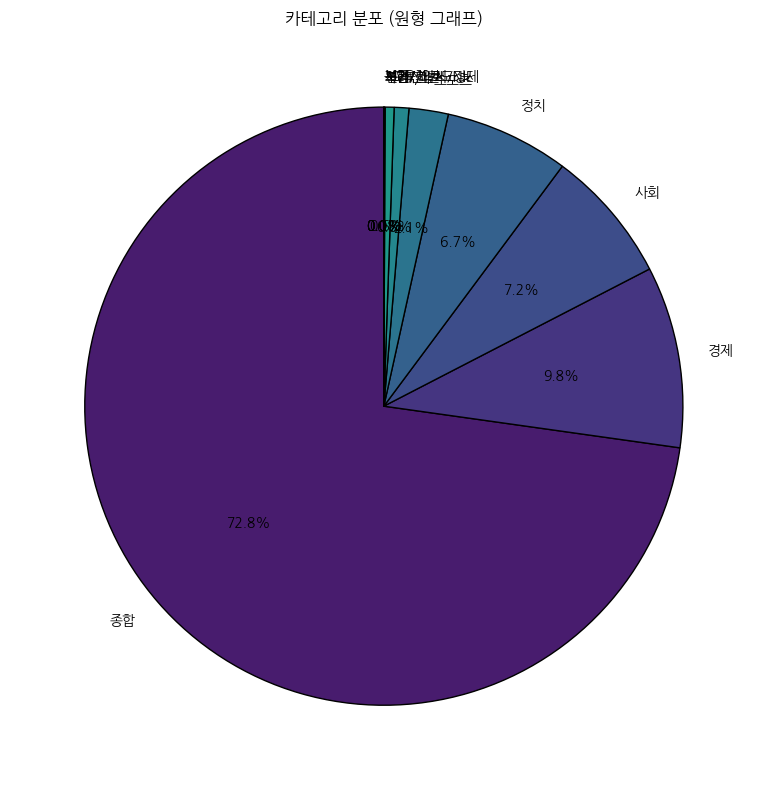

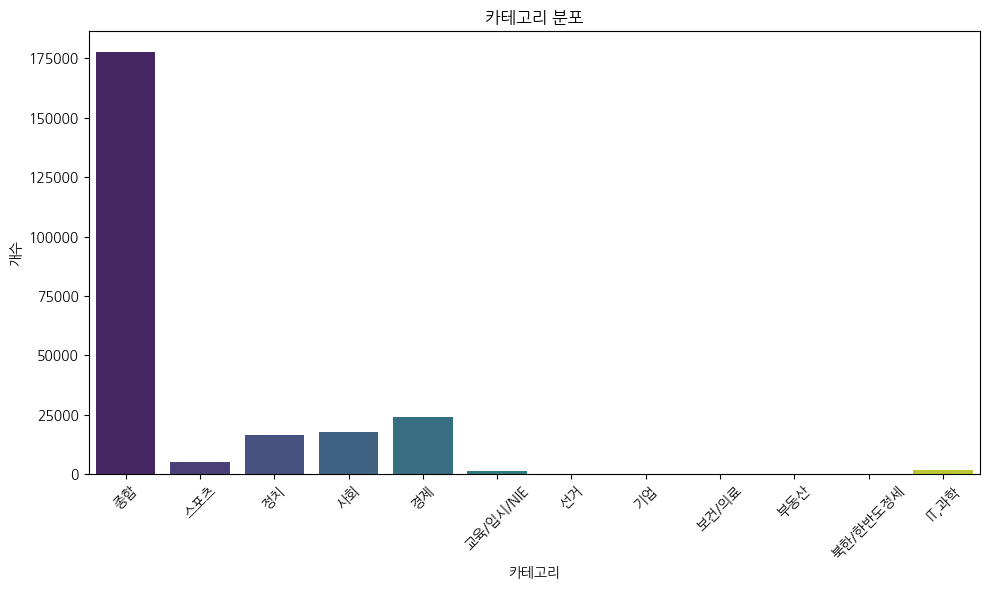

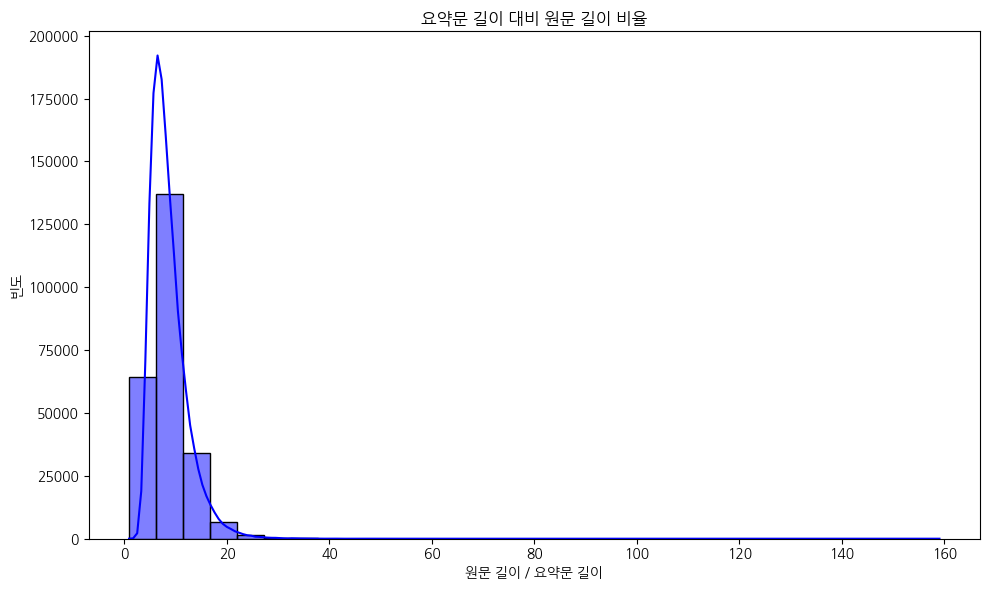

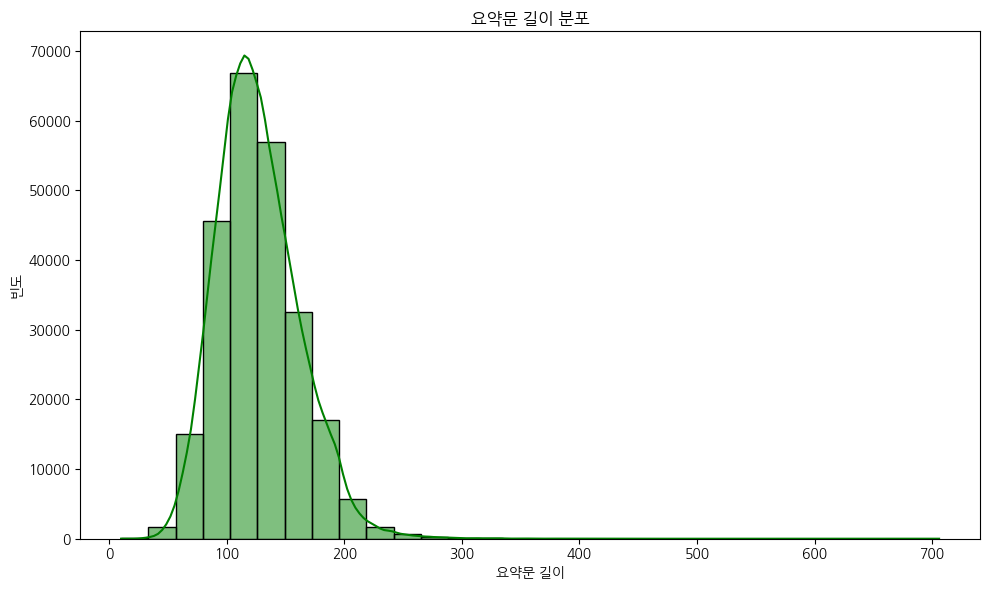

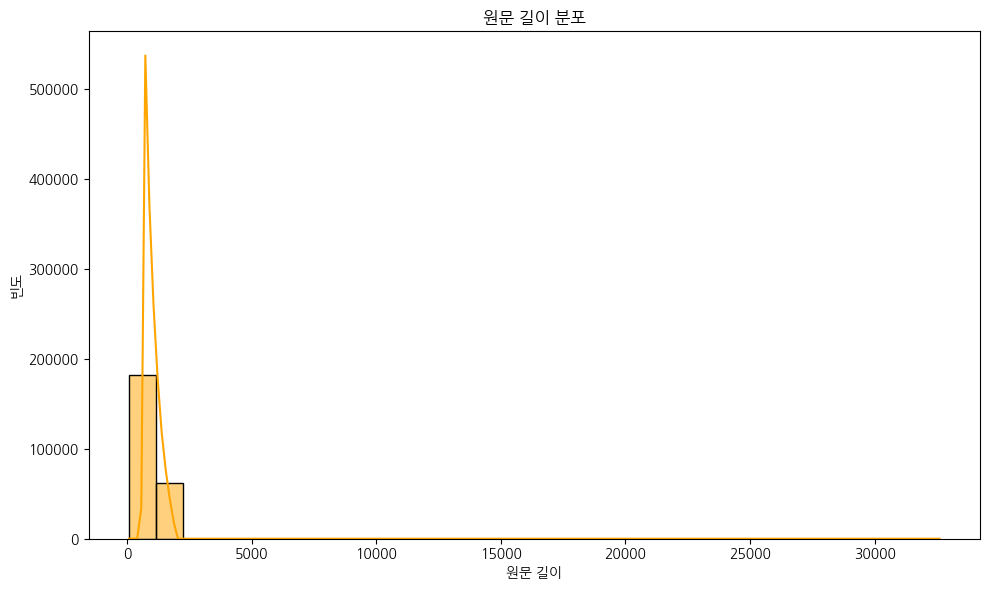

In [145]:
if RUN_PROCESS['원본데이터로드']:
    visualize_data(df_train)


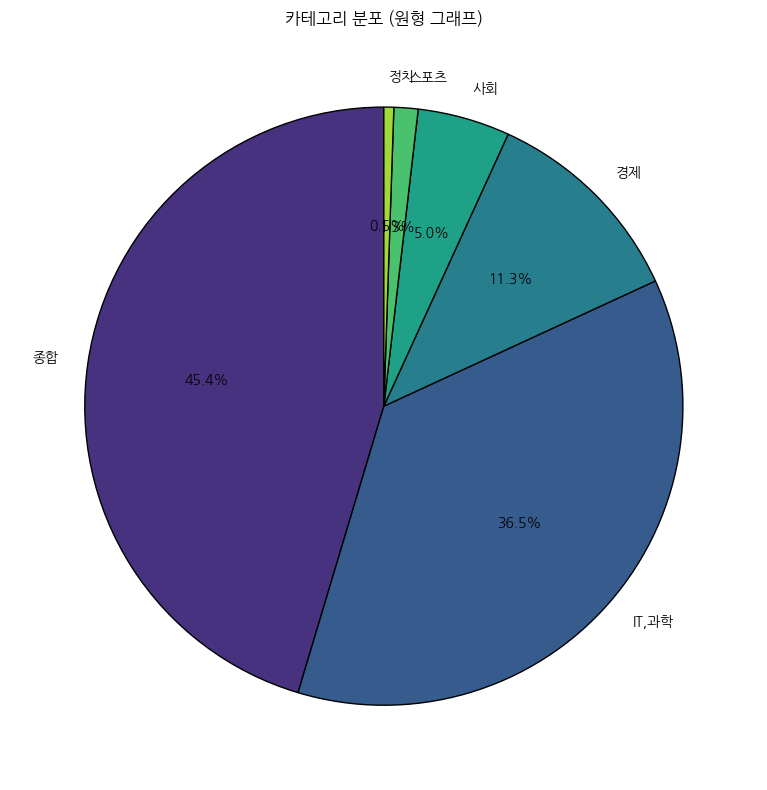

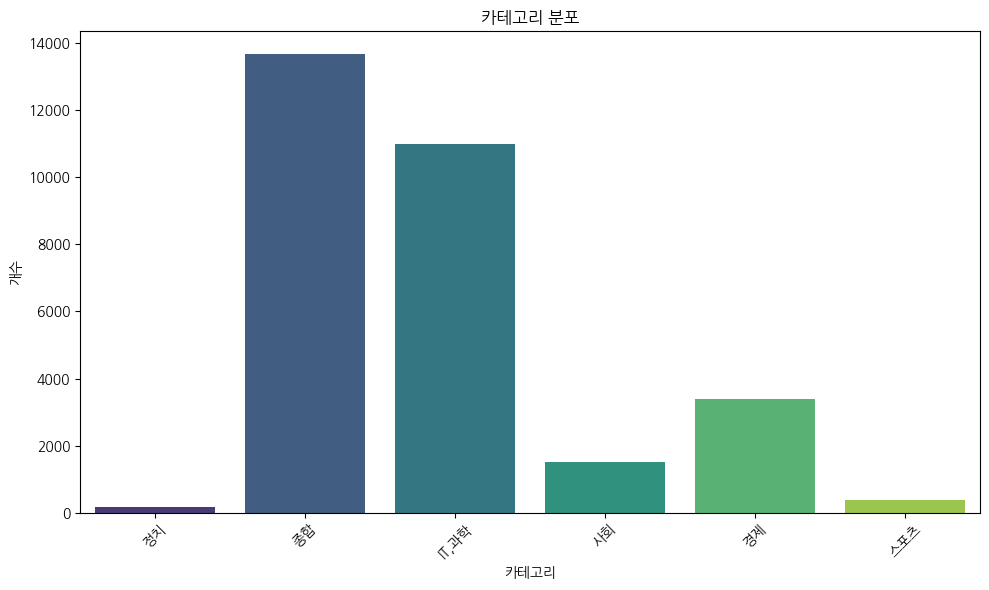

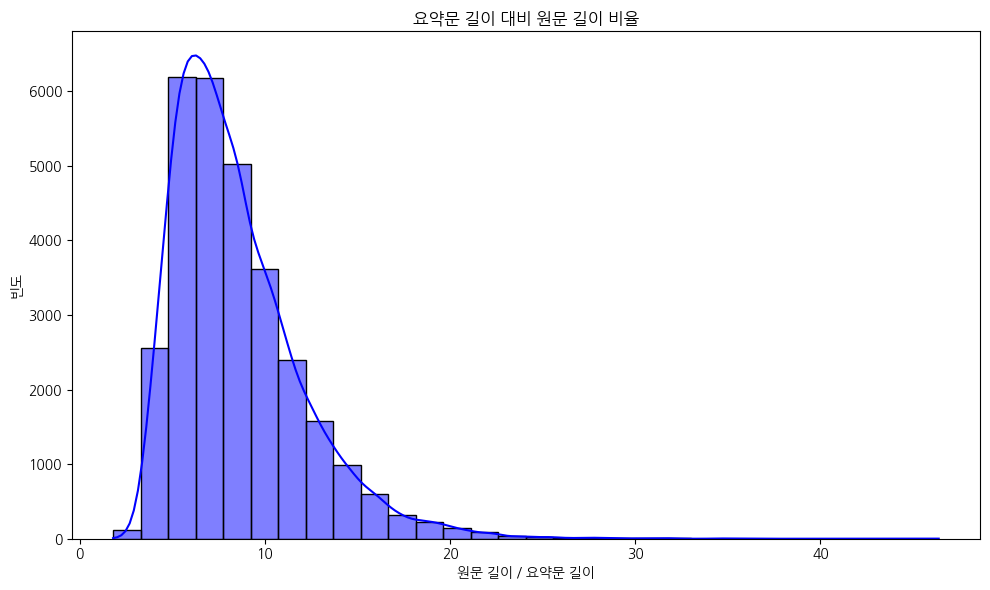

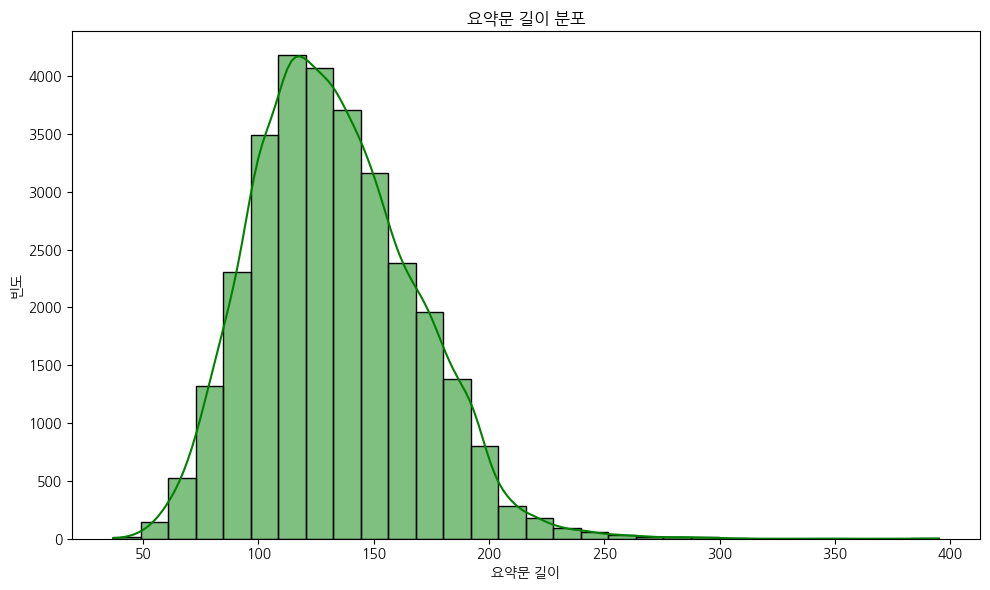

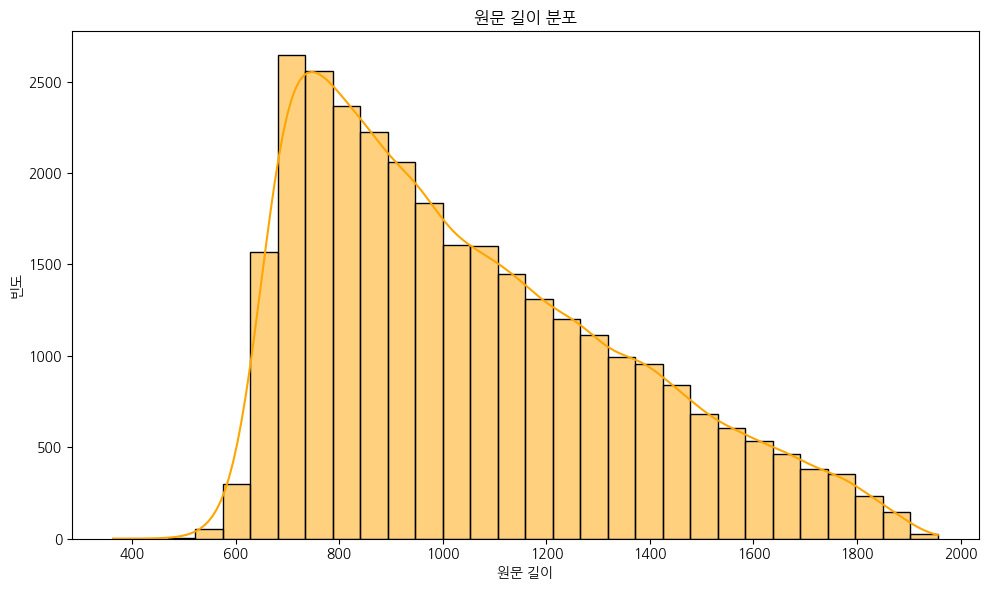

In [146]:
if RUN_PROCESS['원본데이터로드']:
    visualize_data(df_validation)


- 클래스 편중화
    - 장문 요약(Long-form Summarization) 문제에서는 클래스 분포의 편중이 모델 성능에 직접적인 영향을 미치지 않을 가능성이 높다.
    - 장문 요약은 입력 텍스트(문서)를 기반으로 요약문을 생성하는 생성(generative) 문제입니다.
    - 모델은 주어진 입력 텍스트의 의미를 이해하고 요약문을 생성하는 데 초점을 맞추며, 클래스 레이블(카테고리)은 직접적으로 학습 목표에 포함되지 않음.

# >프로그램< 데이타셋 자동화 테스트

In [147]:

if RUN_PROCESS['원본데이터로드']:
    for i in range(2):
        newsfile = newsfiles[i]
        datatype = 'train' if 0 == i else 'validation'
        print(f"JSONL파일: {os.path.exists(newsfile['dest'])} {newsfile['dest']}")
        train_file = Path(newsfile['dest'])

        # 데이터 로드
        dataset = load_dataset("json", data_files={datatype: str(train_file)})

        print(dataset)

        # 데이터셋의 첫 번째 샘플 확인
        print(dataset[datatype][0])

        # 데이터셋의 열(column) 정보 확인
        print(dataset[datatype].column_names)

        # 데이터셋의 전체 통계 확인
        print(dataset[datatype].features)


JSONL파일: True D:\dataset\summarization.zip.unzip_dataset\default\train.jsonl
DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'summary', 'metadata'],
        num_rows: 243979
    })
})
{'id': '290741778', 'document': '논 타작물 재배 2월 말까지 신청하세요 ha당 조사료 400만원 작물별 차등 지원 이성훈 전라남도가 쌀 과잉문제를 근본적으로 해결하기 위해 올해부터 시행하는 쌀 생산조정제를 적극 추진키로 했다. 쌀 생산조정제는 벼를 심었던 논에 벼 대신 사료작물이나 콩 등 다른 작물을 심으면 벼와의 일정 소득차를 보전해주는 제도다. 올해 전남의 논 다른 작물 재배 계획면적은 전국 5만ha의 약 21 인 1만 698ha로 세부시행지침을 확정 시군에 통보했다. 지원사업 대상은 2017년산 쌀 변동직불금을 받은 농지에 10a 300평 이상 벼 이외 다른 작물을 재배한 농업인이다. 지원 대상 작물은 1년생을 포함한 다년생의 모든 작물이 해당되나 재배 면적 확대 시 수급과잉이 우려되는 고추 무 배추 인삼 대파 등 수급 불안 품목은 제외된다. 농지의 경우도 이미 다른 작물 재배 의무가 부여된 간척지 정부매입비축농지 농진청 시범사업 경관보전 직불금 수령 농지 등은 제외될 예정이다. ha 3000평 당 지원 단가는 평균 340만원으로 사료작물 400만원 일반작물은 340만원 콩·팥 등 두류작물은 280만원 등이다. 벼와 소득차와 영농 편이성을 감안해 작물별로 차등 지원된다. 논에 다른 작물 재배를 바라는 농가는 오는 22일부터 2월 28일까지 농지 소재지 읍면동사무소에 신청해야 한다. 전남도는 도와 시군에 관련 기관과 농가 등이 참여하는 논 타작물 지원사업 추진협의회 를 구성 지역 특성에 맞는 작목 선정 및 사업 심의 등을 본격 추진할 방침이다. 최향철 전라남도 친환

In [148]:
if RUN_PROCESS['원본데이터로드']:
    zip_file_src = r'D:\dataset\summarization.zip.unzip_dataset'
    zip_file_dest = r'D:\dataset\summarization_cleaned.zip'
    zip_progress(input_path=zip_file_src, zip_path=zip_file_dest)
    logger.debug(f"작업 완료. {os.path.exists(zip_file_dest)} {zip_file_dest}")


Zipping:   0%|          | 0/2 [00:00<?, ?file/s]

# >프로그램< 데이타 다운로드

In [149]:
drive_temp_path = get_path_temp()
os.makedirs(drive_temp_path, exist_ok=True)
drive_temp_summarization_cleaned_path = os.path.join(drive_temp_path, r'summarization_cleaned.zip')

logger.info(f"temp path: {drive_temp_path}")
logger.info(f"temp download path: {drive_temp_summarization_cleaned_path}")

url_clean_zip = r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzk4ODIwNTI2NTUwNHxGfDA&svcType=MYBOX-WEB&time=1761021525136'
download_http(url_clean_zip, drive_temp_summarization_cleaned_path, ignore=False)


2025-10-24 17:44:35 [I] temp path: d:\temp
2025-10-24 17:44:35 [I] temp download path: d:\temp\summarization_cleaned.zip


이미 파일이 존재합니다: d:\temp\summarization_cleaned.zip


'd:\\temp\\summarization_cleaned.zip'

In [150]:
unzip_summarization_cleaned_path = unzip([drive_temp_summarization_cleaned_path], remove_zip=False)
logger.debug(f"압축해제 완료: {unzip_summarization_cleaned_path}")

이미 압축 해제됨: d:\temp\summarization_cleaned.zip.unzip


In [151]:
# import pandas as pd
# import json
# from pathlib import Path
# import random
# import shutil

def split_train_test(train_path, test_path, overwrite_train=False, backup_train=True):
    """
    train.jsonl을 카테고리별로 샘플링하여 test.jsonl 생성.

    Args:
        train_path (str): train.jsonl 파일 경로.
        test_path (str): 생성할 test.jsonl 파일 경로.
        overwrite_train (bool): train.jsonl 덮어쓰기 여부.
        backup_train (bool): train.jsonl 백업 여부.
    """
    # 파일 경로 설정
    train_file = Path(train_path)
    test_file = Path(test_path)

    # train.jsonl 파일 읽기
    if not train_file.exists():
        raise FileNotFoundError(f"train.jsonl 파일이 존재하지 않습니다: {train_path}")

    if not overwrite_train and os.path.exists(test_file):
        logger.debug(f"test.jsonl 파일이 이미 존재합니다. 덮어쓰기를 방지하기 위해 중단합니다: {test_path}")
        return

    data = pd.read_json(train_file, lines=True, encoding="utf-8")

    # 카테고리별로 그룹화
    grouped = data.groupby(data["metadata"].apply(lambda x: x["category"]))

    test_data = []
    train_data = []

    # 카테고리별 샘플링
    pbar = tqdm(grouped, total=len(grouped), desc="샘플링중")
    for category, group in pbar:
        group_size = len(group)
        if group_size == 1:
            train_data.append(group.iloc[0])  # 1개는 train에 유지
        elif 2 <= group_size <= 10:
            sampled = group.sample(n=1, random_state=42)  # 1개를 test로 이동
            test_data.extend(sampled.to_dict(orient="records"))
            train_data.extend(group.drop(sampled.index).to_dict(orient="records"))
        else:
            test_size = max(1, int(group_size * 0.1))  # 10% 샘플링
            sampled = group.sample(n=test_size, random_state=42)
            test_data.extend(sampled.to_dict(orient="records"))
            train_data.extend(group.drop(sampled.index).to_dict(orient="records"))

    # test.jsonl 저장
    with open(test_file, "w", encoding="utf-8") as f:
        for record in test_data:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")

    # train.jsonl 덮어쓰기 또는 백업
    if backup_train:
        backup_path = train_file.with_suffix(".backup.jsonl")
        shutil.copy(train_file, backup_path)

    with open(train_file, "w", encoding="utf-8") as f:
        for record in train_data:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")

    print(f"train.jsonl: {len(train_data)}개, test.jsonl: {len(test_data)}개로 분리 완료.")

train_path = os.path.join(unzip_summarization_cleaned_path[0], 'default', 'train.jsonl')
validation_path = os.path.join(unzip_summarization_cleaned_path[0], 'default', 'validation.jsonl')
test_path = os.path.join(unzip_summarization_cleaned_path[0], 'default', 'test.jsonl')

if RUN_PROCESS['전처리데이터로드']:
    split_train_test(train_path, test_path, overwrite_train=False, backup_train=False)

In [152]:
# File: test_12_3팀_김명환.ipynb
# import os
# from datasets import load_dataset
# import pandas as pd

def test_dataset_loading_and_distribution():
    # Define dataset paths
    train_path = os.path.join(unzip_summarization_cleaned_path[0], 'default', 'train.jsonl')
    validation_path = os.path.join(unzip_summarization_cleaned_path[0], 'default', 'validation.jsonl')
    test_path = os.path.join(unzip_summarization_cleaned_path[0], 'default', 'test.jsonl')

    # Load datasets
    dataset_train = load_dataset("json", data_files={'train': str(train_path)})
    dataset_validation = load_dataset("json", data_files={'validation': str(validation_path)})
    dataset_test = load_dataset("json", data_files={'test': str(test_path)})

    # Assertions to verify datasets are loaded
    assert len(dataset_train['train']) > 0, "Train dataset is empty"
    assert len(dataset_validation['validation']) > 0, "Validation dataset is empty"
    assert len(dataset_test['test']) > 0, "Test dataset is empty"

    # Check column names
    expected_columns = ['id', 'document', 'summary', 'metadata']
    assert all(col in dataset_train['train'].column_names for col in expected_columns), "Train dataset columns mismatch"
    assert all(col in dataset_validation['validation'].column_names for col in expected_columns), "Validation dataset columns mismatch"
    assert all(col in dataset_test['test'].column_names for col in expected_columns), "Test dataset columns mismatch"

    # Calculate category distribution
    def calculate_distribution(dataset, split_name):
        df = pd.DataFrame(dataset[split_name])
        df['category'] = df['metadata'].apply(lambda x: x['category'])
        category_distribution = df['category'].value_counts().reset_index()
        category_distribution.columns = ['Category', 'Count']
        return category_distribution

    train_distribution = calculate_distribution(dataset_train, 'train')
    validation_distribution = calculate_distribution(dataset_validation, 'validation')
    test_distribution = calculate_distribution(dataset_test, 'test')

    print("Train Dataset Category Distribution:")
    train_distribution.head_att(50)
    print()
    print("Validation Dataset Category Distribution:")
    validation_distribution.head_att(50)
    print()
    print("Test Dataset Category Distribution:")
    test_distribution.head_att(50)

if RUN_PROCESS['전처리데이터로드정보']:
    test_dataset_loading_and_distribution()


Train Dataset Category Distribution:
           Category  Count
  0            종합 159800
  1            경제  21545
  2            사회  15885
  3            정치  14751
  4          스포츠   4657
  5         IT,과학   1738
  6   교육/입시/NIE   1071
  7          부동산     67
  8       보건/의료     50
  9            기업     16
 10 북한/한반도정세      4
 11            선거      1

Validation Dataset Category Distribution:
   Category Count
 0     종합 13666
 1  IT,과학 10997
 2     경제  3403
 3     사회  1503
 4   스포츠   392
 5     정치   161

Test Dataset Category Distribution:
           Category Count
  0            종합 17755
  1            경제  2393
  2            사회  1764
  3            정치  1638
  4          스포츠   517
  5         IT,과학   193
  6   교육/입시/NIE   119
  7          부동산     7
  8       보건/의료     5
  9            기업     1
 10 북한/한반도정세     1
 11            선거     1


In [153]:
# from datasets import load_dataset
# from transformers import AutoTokenizer

# # 경로 설정
# from pathlib import Path

train_path = os.path.join(unzip_summarization_cleaned_path[0], 'default', 'train.jsonl')
validation_path = os.path.join(unzip_summarization_cleaned_path[0], 'default', 'validation.jsonl')
test_path = os.path.join(unzip_summarization_cleaned_path[0], 'default', 'test.jsonl')

dataset_train = load_dataset("json", data_files={'train': str(train_path)})
dataset_validation = load_dataset("json", data_files={'validation': str(validation_path)})
dataset_test = load_dataset("json", data_files={'test': str(test_path)})

if RUN_PROCESS['전처리데이터로드정보']:

    logger.info("Train")
    logger.info(dataset_train)
    logger.info(dataset_train['train'][0])
    logger.info(dataset_train['train'].column_names)
    logger.info(dataset_train['train'].features)

    logger.info("Validation")
    logger.info(dataset_validation)
    logger.info(dataset_validation['validation'][0])
    logger.info(dataset_validation['validation'].column_names)
    logger.info(dataset_validation['validation'].features)

    logger.info("Test")
    logger.info(dataset_test)
    logger.info(dataset_test['test'][0])
    logger.info(dataset_test['test'].column_names)
    logger.info(dataset_test['test'].features)


2025-10-24 17:45:15 [I] Train
2025-10-24 17:45:15 [I] DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'summary', 'metadata'],
        num_rows: 219585
    })
})
2025-10-24 17:45:15 [I] {'id': 358249366, 'document': '글로벌 스마트폰 판매 하락 속 삼성 선전 20 대 점유율 돌파 올해 2분기 전 세계 스마트폰 판매량은 하락세를 기록했으나 삼성전자는 6분기 연속 하락 끝에 상승세를 회복한 것으로 나타났다. 해당 기간 삼성전자 스마트폰 전 세계 시장 점유율은 20 대를 돌파했다. 31일 글로벌 IT 자문기관 가트너에 따르면 올 2분기 전 세계 스마트폰 판매량은 전년 동기 대비 1.7 감소한 3억6800만 대로 집계됐다. 안슐 굽타 가트너의 책임연구원은 고급 스마트폰의 수요가 중저가 보급형 스마트폰의 수요보다 훨씬 더 큰 폭으로 둔화됐다 며 제조업체들은 스마트폰 교체를 유도하기 위해 전·후면 멀티렌즈 카메라 베젤리스 디스플레이 대용량 배터리 등 플래그십 스마트폰의 프리미엄 기능을 저가 스마트폰에 탑재했다 고 말했다. 올해 2분기 상위 5대 글로벌 스마트폰 업체 중 화웨이와 삼성은 각각 16.5 와 3.8 의 높은 연간 매출 증가율을 기록했다. 안슐 굽타 책임연구원은 결과적으로 화웨이와 삼성의 2분기 시장 점유율이 상승했고 이 두 업체의 판매량은 전 세계 스마트폰 판매량의 3분의 1 이상을 차지하게 됐다 고 말했다. 화웨이에 대한 규제가 연기되면서 판매량이 소폭 개선됐으나 규제 발표의 여파로 인해 올해 2분기 세계 시장에서의 화웨이 스마트폰 판매량은 이미 급격히 감소한 상태다. 전 세계적으로 모든 스마트폰 판매가 약세를 보였지만 화웨이는 적극적인 프로모션과 브랜드 포지셔닝을 통해 중화권에서 기록적인 판매량을 달성하며 31 성장했다. 삼성전자는 올 2분기에 75

# >프로그램< 로직테스트를 위하여 데이타셋을 10개로

In [154]:
if RUN_PROCESS['데이터셋10']:
    # 데이터셋 로드
    dataset_train = load_dataset("json", data_files={'train': str(train_path)})
    dataset_validation = load_dataset("json", data_files={'validation': str(validation_path)})
    dataset_test = load_dataset("json", data_files={'test': str(test_path)})

    # 각 데이터셋에서 상위 10개 샘플만 선택
    dataset_train['train'] = dataset_train['train'].select(range(10))
    dataset_validation['validation'] = dataset_validation['validation'].select(range(10))
    dataset_test['test'] = dataset_test['test'].select(range(10))

    # 결과 출력
    logger.info(f"Train Dataset: {len(dataset_train['train'])} samples")
    logger.info(f"Validation Dataset: {len(dataset_validation['validation'])} samples")
    logger.info(f"Test Dataset: {len(dataset_test['test'])} samples")

In [155]:
from huggingface_hub import login, notebook_login
from dotenv import load_dotenv
import os
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
else:
    notebook_login()
logger.info("huggingface_hub logged in.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
2025-10-24 17:45:16 [W] Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
2025-10-24 17:45:16 [I] huggingface_hub logged in.


In [156]:
from huggingface_hub import snapshot_download
from transformers import AutoTokenizer, PreTrainedTokenizerFast, BartModel

if RUN_PROCESS['테스트_kobart-base-v1']:
    model_name = "skt/kobart-base-v1"
    tokenizer = PreTrainedTokenizerFast.from_pretrained(model_name)
    model = BartModel.from_pretrained(model_name)

    # 어휘 사전 크기 확인
    vocab_size = len(tokenizer)
    print(f"로드된 어휘 사전의 크기: {vocab_size}")

    logger.info(f"토크나이저 및 모델 로드 완료: {model_name}")

    # snapshot_download 함수를 사용하여 모델 및 토크나이저 파일들이
    # 모두 저장된 캐시 폴더의 루트 경로를 가져옵니다.
    # (파일이 이미 있으면 다시 다운로드하지 않고 경로만 반환합니다.)
    cache_path = snapshot_download(repo_id=model_name)

    print("-" * 40)
    print(f"KoBART ({model_name})의 로컬 캐시 경로:")
    print(f"{cache_path}")
    print("-" * 40)

    # 해당 경로 내의 주요 토크나이저 파일 확인
    print("디렉토리 내 주요 토크나이저 파일:")
    if os.path.exists(cache_path):
        # KoBART는 Fast Tokenizer (BPE 기반)를 사용하므로 'tokenizer.json'과 'vocab.json'이 중요합니다.
        for filename in ["config.json", "pytorch_model.bin", "tokenizer.json", "vocab.json", "special_tokens_map.json"]:
            file_path = os.path.join(cache_path, filename)
            if os.path.exists(file_path):
                print(f"- {filename} (존재함)")
    else:
        print("경로를 찾을 수 없거나 파일이 존재하지 않습니다.")


# >프로그램< 전처리 유지 단어 토큰 등록 여부 확인

In [157]:
for txt in DOMAIN_TERMS:
    logger.info(f"도메인 용어: {txt}")

2025-10-24 17:45:16 [I] 도메인 용어: ℃
2025-10-24 17:45:16 [I] 도메인 용어: ㎍/㎥
2025-10-24 17:45:16 [I] 도메인 용어: ㎡
2025-10-24 17:45:16 [I] 도메인 용어: M&A
2025-10-24 17:45:16 [I] 도메인 용어: R&D
2025-10-24 17:45:16 [I] 도메인 용어: C++
2025-10-24 17:45:16 [I] 도메인 용어: %P
2025-10-24 17:45:16 [I] 도메인 용어: b/d
2025-10-24 17:45:16 [I] 도메인 용어: KT&G
2025-10-24 17:45:16 [I] 도메인 용어: ExiPrep™96 Lite


In [158]:
if RUN_PROCESS['테스트_kobart-base-v1']:
    # 추가하려는 도메인 어휘 목록
    new_domain_words = DOMAIN_TERMS
    words_to_add = []
    words_already_exist = []

    for word in new_domain_words:
        # 1. 단어를 토큰 ID로 변환해봅니다.
        # 만약 단어가 어휘 사전에 있으면 해당 ID를 반환합니다.
        # 단, 'unk_token' ID(일반적으로 5)와 헷갈리지 않도록 주의해야 합니다.
        token_id = tokenizer.convert_tokens_to_ids(word)

        # 2. 결과 확인
        # 만약 변환된 ID가 'unk_token'(알 수 없는 토큰)의 ID가 아니라면, 이미 등록된 토큰입니다.
        if token_id is not None and token_id != tokenizer.unk_token_id:
            words_already_exist.append(word)
        else:
            words_to_add.append(word)

    print(f"이미 등록된 어휘 (추가할 필요 없음): {words_already_exist}")
    print(f"새로 추가해야 할 어휘: {words_to_add}")

In [159]:
# 모델 및 토크나이저 로드
model_name = "skt/kobart-base-v1"
tokenizer = PreTrainedTokenizerFast.from_pretrained(model_name)
model = BartModel.from_pretrained(model_name)

print(f"모델 최대 토큰 길이: {tokenizer.model_max_length}")
print(f"어휘 사전 크기: {len(tokenizer)}")
print()

# 도메인 특화 어휘
DOMAIN_TERMS = ['M&A', '㎍/㎥', 'C++', 'ExiPrep™96 Lite', 'R&D',
                'b/d', 'KT&G', '㎡', '℃', '%P']

# 기존에 등록된 어휘 확인
words_to_add = []
for word in DOMAIN_TERMS:
    token_id = tokenizer.convert_tokens_to_ids(word)
    if token_id is None or token_id == tokenizer.unk_token_id:
        words_to_add.append(word)

# 새로 추가해야 할 어휘만 추가
if words_to_add:
    num_added = tokenizer.add_tokens(words_to_add)
    print(f"새로 추가된 토큰 수: {num_added}")
    print(f"업데이트된 어휘 사전 크기: {len(tokenizer)}")
    model.resize_token_embeddings(len(tokenizer))
else:
    print("모든 도메인 특화 어휘가 이미 등록되어 있습니다.")
print()

# 데이터셋 로드 (경로는 실제 경로로 변경하세요)
# dataset_train = load_dataset("json", data_files={'train': 'train.json'})
# dataset_validation = load_dataset("json", data_files={'validation': 'validation.json'})
# dataset_test = load_dataset("json", data_files={'test': 'test.json'})

def analyze_token_lengths(dataset, split_name, sample_size=None):
    """
    데이터셋의 토큰 길이를 분석하는 함수

    Args:
        dataset: HuggingFace Dataset 객체
        split_name: 데이터셋 분할 이름 (train/validation/test)
        sample_size: 샘플링할 데이터 수 (None이면 전체 사용)
    """
    data = dataset[split_name]

    if sample_size and sample_size < len(data):
        indices = np.random.choice(len(data), sample_size, replace=False)
        data = data.select(indices)

    doc_lengths = []
    sum_lengths = []

    print(f"\n{'='*60}")
    print(f"{split_name.upper()} 데이터셋 토큰 길이 분석")
    print(f"{'='*60}")
    print(f"분석 데이터 수: {len(data)}")

    for example in tqdm(data, desc=f"Tokenizing {split_name}"):
        # Document 토큰화
        doc_tokens = tokenizer(
            example['document'],
            truncation=False,
            add_special_tokens=True
        )
        doc_lengths.append(len(doc_tokens['input_ids']))

        # Summary 토큰화
        sum_tokens = tokenizer(
            example['summary'],
            truncation=False,
            add_special_tokens=True
        )
        sum_lengths.append(len(sum_tokens['input_ids']))

    # 통계 계산
    doc_stats = {
        '평균': np.mean(doc_lengths),
        '중앙값': np.median(doc_lengths),
        '표준편차': np.std(doc_lengths),
        '최소': np.min(doc_lengths),
        '최대': np.max(doc_lengths),
        '25%': np.percentile(doc_lengths, 25),
        '75%': np.percentile(doc_lengths, 75),
        '90%': np.percentile(doc_lengths, 90),
        '95%': np.percentile(doc_lengths, 95),
        '99%': np.percentile(doc_lengths, 99)
    }

    sum_stats = {
        '평균': np.mean(sum_lengths),
        '중앙값': np.median(sum_lengths),
        '표준편차': np.std(sum_lengths),
        '최소': np.min(sum_lengths),
        '최대': np.max(sum_lengths),
        '25%': np.percentile(sum_lengths, 25),
        '75%': np.percentile(sum_lengths, 75),
        '90%': np.percentile(sum_lengths, 90),
        '95%': np.percentile(sum_lengths, 95),
        '99%': np.percentile(sum_lengths, 99)
    }

    # 모델 최대 길이 초과 비율 계산
    max_length = tokenizer.model_max_length
    doc_exceed_ratio = np.sum(np.array(doc_lengths) > max_length) / len(doc_lengths) * 100
    sum_exceed_ratio = np.sum(np.array(sum_lengths) > max_length) / len(sum_lengths) * 100

    print("\n[Document 토큰 길이 통계]")
    for key, value in doc_stats.items():
        print(f"  {key:8s}: {value:8.2f}")
    print(f"  최대 길이({max_length}) 초과: {doc_exceed_ratio:.2f}%")

    print("\n[Summary 토큰 길이 통계]")
    for key, value in sum_stats.items():
        print(f"  {key:8s}: {value:8.2f}")
    print(f"  최대 길이({max_length}) 초과: {sum_exceed_ratio:.2f}%")

    return doc_lengths, sum_lengths, doc_stats, sum_stats


def visualize_token_distribution(doc_lengths, sum_lengths, split_name, max_length=1024):
    """
    토큰 길이 분포를 시각화하는 함수
    """
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle(f'{split_name.upper()} 데이터셋 토큰 길이 분포', fontsize=16, fontweight='bold')

    # Document 히스토그램
    axes[0, 0].hist(doc_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(max_length, color='red', linestyle='--', linewidth=2, label=f'Max Length ({max_length})')
    axes[0, 0].axvline(np.mean(doc_lengths), color='green', linestyle='--', linewidth=2, label=f'평균 ({np.mean(doc_lengths):.0f})')
    axes[0, 0].set_xlabel('토큰 길이')
    axes[0, 0].set_ylabel('빈도')
    axes[0, 0].set_title('Document 토큰 길이 분포')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Summary 히스토그램
    axes[0, 1].hist(sum_lengths, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(max_length, color='red', linestyle='--', linewidth=2, label=f'Max Length ({max_length})')
    axes[0, 1].axvline(np.mean(sum_lengths), color='green', linestyle='--', linewidth=2, label=f'평균 ({np.mean(sum_lengths):.0f})')
    axes[0, 1].set_xlabel('토큰 길이')
    axes[0, 1].set_ylabel('빈도')
    axes[0, 1].set_title('Summary 토큰 길이 분포')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Document 박스플롯
    axes[1, 0].boxplot(doc_lengths, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='skyblue', alpha=0.7))
    axes[1, 0].axvline(max_length, color='red', linestyle='--', linewidth=2, label=f'Max Length ({max_length})')
    axes[1, 0].set_xlabel('토큰 길이')
    axes[1, 0].set_title('Document 토큰 길이 박스플롯')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Summary 박스플롯
    axes[1, 1].boxplot(sum_lengths, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[1, 1].axvline(max_length, color='red', linestyle='--', linewidth=2, label=f'Max Length ({max_length})')
    axes[1, 1].set_xlabel('토큰 길이')
    axes[1, 1].set_title('Summary 토큰 길이 박스플롯')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)


    # Document 바이올린 플롯
    sns.violinplot(data=doc_lengths, ax=axes[2, 0], color='skyblue')
    axes[2, 0].axhline(max_length, color='red', linestyle='--', linewidth=2, label=f'Max Length ({max_length})')
    axes[2, 0].set_xlabel('토큰 길이')
    axes[2, 0].set_title('Document 토큰 길이 분포 (바이올린 플롯)')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)

    # Summary 바이올린 플롯
    sns.violinplot(data=sum_lengths, ax=axes[2, 1], color='lightcoral')
    axes[2, 1].axhline(max_length, color='red', linestyle='--', linewidth=2, label=f'Max Length ({max_length})')
    axes[2, 1].set_xlabel('토큰 길이')
    axes[2, 1].set_title('Summary 토큰 길이 분포 (바이올린 플롯)')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'mission_11_{split_name}_token_distribution.png', dpi=300, bbox_inches='tight')
    print(f"\n시각화 저장: mission_11_{split_name}_token_distribution.png")
    plt.show()


def compare_all_splits(train_doc, train_sum, val_doc, val_sum, test_doc, test_sum):
    """
    모든 데이터셋 분할의 토큰 길이를 비교하는 함수
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('전체 데이터셋 토큰 길이 비교', fontsize=16, fontweight='bold')

    # Document 비교
    data_doc = [train_doc, val_doc, test_doc]
    axes[0].boxplot(data_doc, labels=['Train', 'Validation', 'Test'],
                    patch_artist=True,
                    boxprops=dict(facecolor='skyblue', alpha=0.7))
    axes[0].set_ylabel('토큰 길이')
    axes[0].set_title('Document 토큰 길이 비교')
    axes[0].grid(True, alpha=0.3)

    # Summary 비교
    data_sum = [train_sum, val_sum, test_sum]
    axes[1].boxplot(data_sum, labels=['Train', 'Validation', 'Test'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[1].set_ylabel('토큰 길이')
    axes[1].set_title('Summary 토큰 길이 비교')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('mission_11_all_splits_comparison.png', dpi=300, bbox_inches='tight')
    print("\n전체 비교 시각화 저장: mission_11_all_splits_comparison.png")
    plt.show()


You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


모델 최대 토큰 길이: 1000000000000000019884624838656
어휘 사전 크기: 30000

새로 추가된 토큰 수: 10
업데이트된 어휘 사전 크기: 30010



In [160]:
if RUN_PROCESS['학습_정보']:
    # 전체 데이터셋 분석
    train_doc, train_sum, _, _ = analyze_token_lengths(dataset_train, 'train')
    val_doc, val_sum, _, _ = analyze_token_lengths(dataset_validation, 'validation')
    test_doc, test_sum, _, _ = analyze_token_lengths(dataset_test, 'test')

    # 개별 시각화
    visualize_token_distribution(train_doc, train_sum, 'train')
    visualize_token_distribution(val_doc, val_sum, 'validation')
    visualize_token_distribution(test_doc, test_sum, 'test')

    # 전체 비교
    compare_all_splits(train_doc, train_sum, val_doc, val_sum, test_doc, test_sum)


# >설명<
- 기본 토큰 최대 사이즈
    - "max_position_embeddings": 1026,
    - 실제 문자가 어휘사전을 통하여 토큰화 되면 토큰 수 보다 글자수는 더 많아 진다.
    - 학습 데이타의 최대 토큰수는 0.01% 미만으로 무시 해도 되는 수준으로 판단되어 토큰 수 조정 없이 학습한다.

* 학습 데이타 토큰 개수

| **통계 항목** | **값**       |
|---------------|--------------|
| 평균          | 425.91       |
| 중앙값        | 396.00       |
| 표준편차      | 126.53       |
| 최소          | 39.00        |
| 최대          | 14419.00     |
| 25%           | 330.00       |
| 75%           | 497.00       |
| 90%           | 607.00       |
| 95%           | 673.00       |
| 99%           | 773.00       |

In [161]:
from typing import Optional, List, Dict
import wandb
import os

try:
    import wandb
    logger.debug(f"wandb 설치됨: 버전 {wandb.__version__} — 설치 생략")
except Exception:
    logger.debug("wandb 미설치 감지 — 설치 시작...")
    !pip install -q wandb
    logger.debug("설치 완료: wandb")
    import wandb
!wandb login 86a7b8c07184b2efdfb116546a17b1905e41cb5d

os.environ['WANDB_DISABLE_CODE'] = 'true'  # 코드 저장 차단
os.environ['WANDB_SILENT'] = 'true'  # 불필요한 출력 억제
os.environ['WANDB_IGNORE_GLOBS'] = '*.pth,*.pt,*.ckpt,*.bin'

# WAMDB 설정
class WandbLogger:
    """
    Weights & Biases(WandB) 로깅을 위한 헬퍼 클래스.

    주요 기능:
        - 프로젝트/엔티티/이름/태그/설정 등 wandb.init 파라미터 관리
        - 학습/평가 단계별 지표(wandb.log) 기록
        - 이어학습(run_id) 및 그룹(group) 지원
        - 코드 자동 업로드 차단 옵션(save_code)
        - 세션 종료(wandb.finish) 지원

    Args:
        entity (str, optional): WandB 엔티티(팀/사용자명)
        project (str, optional): 프로젝트명
        name (str, optional): 실험 이름
        job_type (str, optional): job 유형('training', 'evaluation' 등)
        tags (List[str], optional): 태그 리스트
        config (Dict, optional): 실험 설정 딕셔너리
        wandb_run_id (str, optional): 이어학습용 run id
        group (str, optional): 그룹명
        save_code (bool, optional): 코드 업로드 차단 여부

    사용 예시:
        >>> wlog = WandbLogger(entity="c0z0c-dev-home", project="sprint_mission_11", name="TRAIN_Seq2Seq")
        >>> wlog.init()
        >>> wlog.log_train(epoch=1, train_loss=0.5, valid_loss=0.4, valid_metrics={'bleu': 10.2}, duration=120)
        >>> wlog.finish()
    """

    def __init__(self,
                 entity: Optional[str] = None,
                 project: Optional[str] = None,
                 name: Optional[str] = None,
                 job_type: str = 'etc',
                 tags: Optional[List[str]] = None,
                 config: Optional[Dict] = None,
                 wandb_run_id: Optional[str] = None,
                 group: Optional[str] = None,
                 save_code=False,
                 ):
        self.entity = entity
        self.project = project
        self.name = name
        self.job_type = job_type
        self.tags = tags
        self.config = config
        self.run = None
        self.wandb_run_id = wandb_run_id
        self.group = group

        self.kwargs = {
            'project': project,
            'entity': entity,
            'name': name,
            'job_type': job_type,
            'mode': 'online',
            'settings': wandb.Settings(
                start_method='thread',
                console='off',
                save_code=save_code,
                _disable_stats=save_code,
                _disable_meta=save_code,
            )
        }

        # wandb_run_id가 주어지면 이어서 기록
        if self.wandb_run_id is not None:
            self.kwargs['id'] = self.wandb_run_id  # type: ignore
            self.kwargs['resume'] = 'allow'  # type: ignore

        if self.group is not None:
            self.kwargs['group'] = self.group  # type: ignore

        # tags가 None이 아니고 비어있지 않을 때만 추가
        if self.tags is not None and len(self.tags) > 0:
            self.kwargs['tags'] = self.tags  # type: ignore List[str] 타입 그대로 전달 (wandb가 지원)

        # config가 None이 아니고 비어있지 않을 때만 추가
        if self.config is not None and len(self.config) > 0:
            self.kwargs['config'] = self.config  # type: ignore Dict 타입 그대로 전달 (wandb가 지원)

        logger.info(f"Wandb initialized for project: {self.project}")

    def init(self,
                 entity: Optional[str] = None,
                 project: Optional[str] = None,
                 name: Optional[str] = None,
                 job_type: str = 'etc',
                 tags: Optional[List[str]] = None,
                 config: Optional[Dict] = None,
                 wandb_run_id: Optional[str] = None,
                 group: Optional[str] = None,
                 ):
        self.entity = entity
        self.project = project
        self.name = name
        self.job_type = job_type
        self.tags = tags
        self.config = config
        self.group = group

        if self.project is not None:
            self.kwargs['project'] = self.project

        if self.entity is not None:
            self.kwargs['entity'] = self.entity

        if self.name is not None:
            self.kwargs['name'] = self.name

        if self.job_type is not None:
            self.kwargs['job_type'] = self.job_type

        if self.group is not None:
            self.kwargs['group'] = self.group

        if self.tags is not None and len(self.tags) > 0:
            self.kwargs['tags'] = self.tags

        if self.config is not None and len(self.config) > 0:
            self.kwargs['config'] = self.config

        # wandb_run_id가 주어지면 이어서 기록
        if wandb_run_id is not None:
            self.kwargs['id'] = wandb_run_id
            self.kwargs['resume'] = 'allow'

        self.run = wandb.init(**self.kwargs) # type: ignore
        self.wandb_run_id = self.run.id

        logger.info(f"Wandb initialized for project: {project}")
        logger.info(f"Wandb self.kwargs: {self.kwargs}")

    def log_train(self, epoch: int, train_loss: float, valid_loss: float, avg_rouge: float, duration: int):
        """지표 로깅"""
        log_dict = {
            'epoch': epoch,
            'train_loss': train_loss,
            'valid_loss': valid_loss,
            'avg_rouge' : avg_rouge,
            'duration': duration,
        }
        wandb.log(log_dict, step=epoch, commit=True)

    def log_evaluate(self, avg_rouge: float):
        """지표 로깅"""
        log_dict = {
            'avg_rouge' : avg_rouge,
        }
        wandb.log(log_dict, commit=True)

    def finish(self):
        """Wandb 세션 종료"""
        if self.run:
            # 자동 업로드 방지
            # self.run.finish(quiet=True)
            self.run.finish()
        logger.info("Wandb session finished")

In [162]:
def cleanup_cuda_memory(model=None, optimizer=None, scheduler=None):
    """
    CUDA 메모리 정리 함수.

    Args:
        model (optional): PyTorch 모델 객체. 있으면 CPU로 이동 후 삭제.
        optimizer (optional): Optimizer 객체. 있으면 삭제.
        scheduler (optional): Scheduler 객체. 있으면 삭제.

    주요 기능:
        - 모델 및 파이프라인 내 모델을 CPU로 이동하여 GPU 메모리 해제
        - optimizer, scheduler, model, pipeline 객체 삭제
        - 가비지 컬렉션(gc.collect) 및 torch.cuda.empty_cache()로 메모리 완전 정리
        - 정리 후 남은 CUDA 메모리 사용량 로깅
        - 예외 발생 시 경고 로그 출력

    Returns:
        None
    """
    import gc

    try:
        # 모델을 CPU로 이동 후 삭제
        if model is not None:
            try:
                model.to(__device_cpu)
            except Exception:
                pass

        # 객체 삭제
        for obj in [scheduler, optimizer, model]:
            if obj is not None:
                del obj

        # 가비지 컬렉션 + CUDA 캐시 정리
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        logger.debug(f"Memory cleanup: allocated={torch.cuda.memory_allocated()/1e9:.3f}GB")

    except Exception as e:
        logger.warning(f"Memory cleanup failed: {e}")

## 주요 설정값 비교표

| 항목 | config.json | 현재 코드 | 권장값 |
|------|-------------|-----------|--------|
| vocab_size | 30000 | - | 30000 + 추가 토큰 |
| max_position_embeddings | 1026 | - | 1026 (고정) |
| max_source_length | - | 1024 | 1024 |
| max_target_length | - | 128 | 128 |
| truncation | - | True | True |
| bos_token_id | 0 | - | 0 |
| eos_token_id | 1 | - | 1 |
| pad_token_id | 3 | - | 3 |


In [163]:
"""
KoBART 문서 요약 모델 학습 스크립트
"""
# import os
# import torch
# import argparse
# from torch.utils.data import DataLoader
from transformers import (
    BartForConditionalGeneration,
    PreTrainedTokenizerFast,
    get_linear_schedule_with_warmup
)
# from torch.optim import AdamW
# from datasets import load_dataset
# from tqdm import tqdm
# import json

def get_datetime_now_kr():
    """한국 표준시 현재 시간 문자열을 반환합니다."""
    return datetime.now(pytz.timezone('Asia/Seoul')).strftime('%Y%m%d_%H%M%S')


str_time_now_kr = get_datetime_now_kr()

save_dir = str(Path(get_path_modeling()) / f'{model_name}_{str_time_now_kr}')
logger.info(f"모델 저장 디렉토리: {save_dir}")

# 도메인 특화 어휘
DOMAIN_TERMS = ['M&A', 'R&D', 'KT&G', 'C++', '㎍/㎥', '㎡', '℃', '%P', 'b/d']

# 하이퍼파라미터
model_name = "skt/kobart-base-v1"
CONFIG = {
    'model_name': model_name,
    'time': str_time_now_kr,
    'batch_size': 32,  # 8 → 16 (메모리 여유 활용)
    'dataloader_num_workers': 4,  # 병렬 로딩
    'learning_rate': 5e-5,
    'num_epochs': 7,
    'warmup_steps': 500,
    'weight_decay': 0.01,
    'gradient_clip': 1.0,
    'save_dir': save_dir,
    'simple_test' : False,
    'use_wandb' : False,
}

wandb_logger =  WandbLogger(entity="c0z0c-dev-home",
                            project="sprint_mission_12",
                            job_type="training",
                            tags=["training", model_name],
                            config=CONFIG,
                           )

def add_domain_tokens(tokenizer, model):
    """도메인 특화 어휘 추가"""
    words_to_add = []
    for word in DOMAIN_TERMS:
        token_id = tokenizer.convert_tokens_to_ids(word)
        if token_id == tokenizer.unk_token_id:
            words_to_add.append(word)

    if words_to_add:
        tokenizer.add_tokens(words_to_add)
        model.resize_token_embeddings(len(tokenizer))
        print(f"Added {len(words_to_add)} domain tokens")


def preprocess_function(examples, tokenizer):
    """배치 단위 토큰화"""
    # 원문 토큰화
    # max 토큰수가 1026 실제 글자수는 더 많음
    model_inputs = tokenizer(
        examples['document'],
        max_length=1024,
        truncation=True,
        padding='max_length'
    )

    # 요약문 토큰화
    # max 토큰수는 512 실제 글자수는 더 많음
    labels = tokenizer(
        examples['summary'],
        max_length=128,
        truncation=True,
        padding='max_length'
    )

    model_inputs['labels'] = labels['input_ids']
    return model_inputs

def load_and_prepare_data(
    tokenizer,
    train_path: str,
    validation_path: str,
    simple_test: bool = False
) -> tuple:
    """
    데이터셋 로드 및 전처리

    Args:
        tokenizer: HuggingFace 토크나이저
        train_path: train.jsonl 경로
        validation_path: validation.jsonl 경로
        simple_test: 테스트 모드 (10개 샘플만 사용)

    Returns:
        (train_dataset, val_dataset): 전처리된 데이터셋 튜플
    """
    logger.info("Loading dataset...")

    # 경로 검증
    if not Path(train_path).exists():
        raise FileNotFoundError(f"Train path not found: {train_path}")
    if not Path(validation_path).exists():
        raise FileNotFoundError(f"Validation path not found: {validation_path}")

    # 데이터셋 로드
    train_dataset = load_dataset("json", data_files={'train': str(train_path)})
    val_dataset = load_dataset("json", data_files={'validation': str(validation_path)})

    # 테스트 모드: 샘플 수 제한
    if simple_test is True:
        train_dataset['train'] = train_dataset['train'].select(range(10))
        val_dataset['validation'] = val_dataset['validation'].select(range(10))
        logger.info("Simple test mode: 10 samples per split")

    # 전처리 적용
    logger.info("Preprocessing dataset...")
    train_dataset = train_dataset['train'].map(
        lambda x: preprocess_function(x, tokenizer),
        batched=True,
        remove_columns=train_dataset['train'].column_names
    )

    val_dataset = val_dataset['validation'].map(
        lambda x: preprocess_function(x, tokenizer),
        batched=True,
        remove_columns=val_dataset['validation'].column_names
    )

    # PyTorch 형식 변환
    train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
    val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

    logger.info(f"훈련 데이터셋: {len(train_dataset)}개")
    logger.info(f"검증 데이터셋: {len(val_dataset)}개")

    return train_dataset, val_dataset

def train_epoch(model, dataloader, optimizer, scheduler, device):
    """단일 에폭 학습"""
    model.train()
    total_loss = 0

    pbar = tqdm(dataloader, desc="Training")
    for batch in pbar:
        # 데이터를 GPU로 이동
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['gradient_clip'])

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    return total_loss / len(dataloader)


def validate(model, dataloader, tokenizer, device):
    model.eval()
    total_loss = 0
    predictions, references = [], []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validating")
        for batch in pbar:
            # Loss 계산
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

            total_loss += outputs.loss.item()

            # ROUGE용 생성 (배치 단위)
            generated = model.generate(
                input_ids=input_ids,
                max_length=128,
                num_beams=4,
                do_sample=False  # 재현성
            )
            preds = tokenizer.batch_decode(generated, skip_special_tokens=True)
            refs = tokenizer.batch_decode(batch['labels'], skip_special_tokens=True)

            predictions.extend(preds)
            references.extend(refs)

    # ROUGE 계산
    from rouge_score import rouge_scorer
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        scores['rouge1'].append(score['rouge1'].fmeasure)
        scores['rouge2'].append(score['rouge2'].fmeasure)
        scores['rougeL'].append(score['rougeL'].fmeasure)

    avg_rouge = {k: np.mean(v) for k, v in scores.items()}

    return total_loss / len(dataloader), avg_rouge

def save_checkpoint(
    model,
    optimizer,
    scheduler,
    epoch,
    loss,
    history,
    best_loss,
    avg_rouge,
    config,
    filename,
    domain_tokens: list = None  # 추가
):
    """체크포인트 저장 (numpy 객체 변환 + 도메인 토큰 저장)"""
    # history 내 numpy 배열을 Python list로 변환
    serializable_history = {}
    for key, value in history.items():
        if isinstance(value, list):
            serializable_history[key] = [
                float(v) if isinstance(v, (np.floating, np.integer)) else v
                for v in value
            ]
        else:
            serializable_history[key] = value

    # avg_rouge도 float로 변환
    serializable_rouge = {k: float(v) for k, v in avg_rouge.items()}

    checkpoint = {
        'epoch': epoch,
        'model_name': config['model_name'],
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'loss': float(loss),
        'best_loss': float(best_loss),
        'avg_rouge': serializable_rouge,
        'config': config,
        'history': serializable_history
    }

    # 도메인 토큰 저장 (있는 경우)
    if domain_tokens:
        checkpoint['domain_tokens'] = domain_tokens

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    torch.save(checkpoint, filename)
    logger.debug(f"Checkpoint saved: {filename}")
    return filename

def train_main(args):
    # 디바이스 설정
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # 설정 업데이트
    if args.batch_size:
        CONFIG['batch_size'] = args.batch_size
    if args.learning_rate:
        CONFIG['learning_rate'] = args.learning_rate
    if args.num_epochs:
        CONFIG['num_epochs'] = args.num_epochs
    if args.simple_test:
        CONFIG['simple_test'] = args.simple_test
    if args.use_wandb:
        CONFIG['use_wandb'] = args.use_wandb

    print_dic_tree(CONFIG)

    if CONFIG['use_wandb']:
        wandb_logger.init(
            name=f"train_{model_name}_{str_time_now_kr}",
            job_type="training",
            tags=["training", CONFIG['model_name']],
            config=CONFIG,
        )

    # 모델 및 토크나이저 로드
    print("Loading model and tokenizer...")
    tokenizer = PreTrainedTokenizerFast.from_pretrained(CONFIG['model_name'])
    model = BartForConditionalGeneration.from_pretrained(CONFIG['model_name'])

    # 도메인 어휘 추가
    #add_domain_tokens(tokenizer, model)

    # 도메인 어휘 추가
    added_tokens = []
    for word in DOMAIN_TERMS:
        token_id = tokenizer.convert_tokens_to_ids(word)
        if token_id == tokenizer.unk_token_id:
            added_tokens.append(word)

    if added_tokens:
        tokenizer.add_tokens(added_tokens)
        model.resize_token_embeddings(len(tokenizer))
        logger.info(f"Added {len(added_tokens)} domain tokens")

    model.to(device)

    train_path = Path(unzip_summarization_cleaned_path[0]) / 'default' / 'train.jsonl'
    validation_path = Path(unzip_summarization_cleaned_path[0]) / 'default' / 'validation.jsonl'

    # 데이터셋 준비
    train_dataset, val_dataset = load_and_prepare_data(
        tokenizer,
        str(train_path),
        str(validation_path),
        simple_test=CONFIG['simple_test']
    )
    # train_loader = DataLoader(train_dataset,
    #                           batch_size=CONFIG['batch_size'], shuffle=True)
    # val_loader = DataLoader(val_dataset,
    #                         batch_size=CONFIG['batch_size'])

    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=CONFIG['dataloader_num_workers'],
        persistent_workers=True if CONFIG['dataloader_num_workers'] > 0 else False
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG['batch_size'],
        num_workers=CONFIG['dataloader_num_workers'],
    )

    # 옵티마이저 및 스케줄러 설정
    optimizer = AdamW(
        model.parameters(),
        lr=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay']
    )

    total_steps = len(train_loader) * CONFIG['num_epochs']
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=CONFIG['warmup_steps'],
        num_training_steps=total_steps
    )

    end_str = ""
    last_model_path = None
    best_model_path = None

    # 이어학습 처리
    start_epoch = 0
    best_loss = float('inf')
    best_rouge = {}
    #history = {'train_loss': [], 'val_loss': [], 'avg_rouge':[]}
    history = {
        'train_loss': [],
        'val_loss': [],
        'rouge1': [],
        'rouge2': [],
        'rougeL': []
    }

    if args.resume:
        print(f"Resuming from checkpoint: {args.resume}")
        resume_parent = Path(args.resume).parent

        # last_model.pth 경로 생성 및 존재 확인
        last_candidate = resume_parent / "last_model.pth"
        if last_candidate.exists():
            last_model_path = str(last_candidate)
            logger.info(f"last_model.pth 발견: {last_model_path}")

        # best_model.pth 경로 생성 및 존재 확인
        best_candidate = resume_parent / "best_model.pth"
        if best_candidate.exists():
            best_model_path = str(best_candidate)
            logger.info(f"best_model.pth 발견: {best_model_path}")

        checkpoint = torch.load(
            args.resume,
            map_location=device,  # 현재 device에 맞게 자동 매핑
            weights_only=False    # PyTorch 2.6+ 호환
        )

        #print_dic_tree(checkpoint, max_depth=1)
        for key, value in checkpoint.items():
            logger.info(f'checkpoint, key={key}, value_type={type(value)}')

        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_loss = checkpoint['best_loss']
        best_rouge = checkpoint['avg_rouge']
        history = checkpoint['history']
        CONFIG.update(checkpoint['config'])

        #print_dic_tree(history, max_depth=1)

        if CONFIG['num_epochs'] >= start_epoch:
            for i in range(len(history['train_loss'])):
                if CONFIG['use_wandb']:
                    train_loss = history['train_loss'][i]
                    val_loss = history['val_loss'][i]
                    avg_rouge= {
                        'rouge1': history['rouge1'][i],
                        'rouge2': history['rouge2'][i],
                        'rougeL': history['rougeL'][i],
                        }
                    rouge1 = history['rouge1'][i]
                    rouge2 = history['rouge2'][i]
                    rougeL = history['rougeL'][i]

                    wandb_logger.log_train(
                        epoch=i + 1,
                        train_loss=train_loss,
                        valid_loss=val_loss,
                        avg_rouge=avg_rouge,
                        duration=0,
                    )

    # 학습 루프
    print(f"\nStarting training from epoch {start_epoch}...")
    pbar = tqdm(range(start_epoch, CONFIG['num_epochs']), desc="Epochs")
    for epoch in pbar:
        # 학습
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
        history['train_loss'].append(train_loss)

        # 검증
        val_loss, avg_rouge = validate(model, val_loader, tokenizer, device)

        history['val_loss'].append(val_loss)
        history['rouge1'].append(avg_rouge['rouge1'])
        history['rouge2'].append(avg_rouge['rouge2'])
        history['rougeL'].append(avg_rouge['rougeL'])

        if CONFIG['use_wandb']:
            wandb_logger.log_train(
                epoch=epoch + 1,
                train_loss=train_loss,
                valid_loss=val_loss,
                avg_rouge=avg_rouge,
                duration=0,
            )

        # 수정된 부분 (403번째 줄 근처)
        end_str = (
            f"Loss: T={train_loss:.4f} V={val_loss:.4f} "
            f"R1={avg_rouge['rouge1']:.4f} "
            f"R2={avg_rouge['rouge2']:.4f} "
            f"RL={avg_rouge['rougeL']:.4f}"
        )
        pbar.set_postfix_str(end_str)

        last_path = os.path.join(CONFIG['save_dir'], 'last_model.pth')
        last_model_path = save_checkpoint(
            model, optimizer, scheduler, epoch, val_loss,
            history, best_loss, avg_rouge, CONFIG, last_path,
            domain_tokens=added_tokens,
        )

        # Best 모델 저장
        if val_loss < best_loss:
            best_loss = val_loss
            best_rouge = avg_rouge
            best_path = os.path.join(CONFIG['save_dir'], 'best_model.pth')
            best_model_path = save_checkpoint(model, optimizer, scheduler, epoch, val_loss,
                                              history, best_loss, best_rouge, CONFIG, best_path,
                                              domain_tokens=added_tokens,
                                              )
            # print(f"✓ New best model saved! (Val Loss: {val_loss:.4f})")

    print("\n" + "="*50)
    print("Training completed!")
    print(f"Best validation loss: {best_loss:.4f}"
            f"R1={best_rouge['rouge1']:.4f} "
            f"R2={best_rouge['rouge2']:.4f} "
            f"RL={best_rouge['rougeL']:.4f}"
          )
    print("="*50)

    if CONFIG['use_wandb']:
        wandb_logger.finish()

    return last_model_path, best_model_path


2025-10-24 17:45:25 [I] 모델 저장 디렉토리: D:\GoogleDrive\modeling\skt\kobart-base-v1_20251024_174525
2025-10-24 17:45:25 [I] Wandb initialized for project: sprint_mission_12


In [164]:
print_dic_tree(RUN_PROCESS)

├─ 로직테스트 [bool]: False
├─ USE_WANDB [bool]: False
├─ 원본데이터로드 [bool]: True
├─ 전처리데이터다운로드 [bool]: True
├─ 전처리데이터로드 [bool]: True
├─ 전처리데이터로드정보 [bool]: True
├─ 데이터셋10 [bool]: False
├─ 테스트_kobart-base-v1 [bool]: False
├─ 학습_정보 [bool]: False
├─ 학습 [bool]: False
├─ 평가 [bool]: True


In [165]:
if RUN_PROCESS['학습']:
    resume_dir = Path(get_path_modeling()) / f'{model_name}_20251022_170445'
    resume_path = resume_dir / 'last_model.pth'
    logger.info(f"체크포인트 디렉토리 존재 여부: {resume_dir.exists()} ({resume_dir})")
    logger.info(f"체크포인트 파일 존재 여부: {resume_path.exists()} ({resume_path})")

    parser = argparse.ArgumentParser(description='KoBART 문서 요약 모델 학습')
    parser.add_argument('--batch_size', type=int, default=8, help='배치 크기 (기본값: 8)')
    parser.add_argument('--learning_rate', type=float, default=5e-5, help='학습률 (기본값: 5e-5)')
    parser.add_argument('--num_epochs', type=int, default=3, help='에폭 수 (기본값: 3)')
    parser.add_argument('--resume', type=str, default=None, help='체크포인트 경로 (이어학습)')
    parser.add_argument('--simple_test', type=bool, default=False,help='간단 모드 (기본값: False)')
    parser.add_argument('--use_wandb', type=bool, default=False, help='WandB 사용 여부 (기본값: False)')

    # Jupyter 환경 대응: 빈 인자 리스트 전달
    args, unknown = parser.parse_known_args([])
    if unknown:
        logger.debug(f"무시된 인자: {unknown}")

    args.num_epochs = 3 if RUN_PROCESS['데이터셋10'] else CONFIG['num_epochs']
    args.batch_size = CONFIG['batch_size']
    args.resume = str(resume_path) if resume_path.exists() else None
    args.simple_test = True if RUN_PROCESS['데이터셋10'] else False
    args.use_wandb = True if RUN_PROCESS['USE_WANDB'] else False

    logger.info(args)

    print('-' * 80)
    last_model_path, best_model_path = train_main(args)
    cleanup_cuda_memory()

In [166]:
cleanup_cuda_memory()

In [167]:
# Cell 추가: 한글 폰트 경로 가져오기

def get_korean_font_path():
    """
    OS별 한글 폰트 경로 반환
    
    Returns:
        str: 한글 폰트 파일 경로
    """
    import platform
    system = platform.system()
    
    if system == 'Windows':
        return 'C:/Windows/Fonts/malgun.ttf'  # 맑은 고딕
    elif system == 'Darwin':  # macOS
        return '/System/Library/Fonts/AppleGothic.ttf'
    else:  # Linux/Colab
        return '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

In [168]:
"""
KoBART 문서 요약 모델 평가 및 시각화 스크립트
"""
# import os
# import torch
import argparse
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from matplotlib import font_manager
from transformers import BartForConditionalGeneration, PreTrainedTokenizerFast
# from datasets import load_dataset
# from torch.utils.data import DataLoader
# from tqdm import tqdm
from rouge_score import rouge_scorer
from collections import defaultdict
# import random

# # 한글 폰트 설정
# plt.rcParams['font.family'] = 'DejaVu Sans'
# plt.rcParams['axes.unicode_minus'] = False

# 워드클라우드용 한글 폰트 (시스템에 따라 조정 필요)
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("Warning: wordcloud not installed. Skipping wordcloud visualization.")

def load_model_and_tokenizer(checkpoint_path: str):
    """
    체크포인트에서 모델 및 토크나이저 로드

    Args:
        checkpoint_path: .pth 파일 경로

    Returns:
        (model, tokenizer, checkpoint): 모델, 토크나이저, 체크포인트 딕셔너리
    """
    logger.info(f"Loading checkpoint: {checkpoint_path}")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # PyTorch 2.6+ 호환: weights_only=False 명시
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,  # 현재 device에 맞게 자동 매핑
        weights_only=False    # PyTorch 2.6+ 호환
    )

    model_name = checkpoint['model_name']
    logger.info(f"Model: {model_name}")

    # 토크나이저 및 모델 로드
    tokenizer = PreTrainedTokenizerFast.from_pretrained(model_name)
    model = BartForConditionalGeneration.from_pretrained(model_name)

    # 도메인 토큰 복원 (학습 시 추가했다면)
    if 'domain_tokens' in checkpoint:
        domain_tokens = checkpoint['domain_tokens']
        num_added = tokenizer.add_tokens(domain_tokens)
        logger.info(f"Restored {num_added} domain tokens")
        model.resize_token_embeddings(len(tokenizer))

    # 가중치 로드
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    return model, tokenizer, checkpoint

def generate_summary(model, tokenizer, text, device, max_length=128):
    """단일 텍스트 요약 생성"""
    inputs = tokenizer(
        text,
        max_length=1024,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )

    # BART는 token_type_ids를 사용하지 않으므로 제거
    inputs.pop('token_type_ids', None)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=4,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            early_stopping=True
        )

    summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return summary


def calculate_rouge_scores(predictions, references):
    """ROUGE 점수 계산"""
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        scores['rouge1'].append(score['rouge1'].fmeasure)
        scores['rouge2'].append(score['rouge2'].fmeasure)
        scores['rougeL'].append(score['rougeL'].fmeasure)

    # 평균 계산
    avg_scores = {k: np.mean(v) for k, v in scores.items()}
    return avg_scores, scores


def evaluate_model(model, tokenizer, dataset, device, num_samples=None):
    """모델 평가"""
    print("\nEvaluating model...")

    # 수정: len(dataset['test']) 확인 후 슬라이싱
    if num_samples:
        actual_samples = min(num_samples, len(dataset['test']))
        dataset['test'] = dataset['test'].select(range(actual_samples))
        logger.info(f"Selected {actual_samples} samples for evaluation")

    test_data = dataset['test']
    predictions = []
    references = []
    documents = []

    pbar = tqdm(test_data, total=len(test_data), desc="Generating summaries")
    for example in pbar:
        doc = example['document']
        ref = example['summary']

        pred = generate_summary(model, tokenizer, doc, device)

        documents.append(doc)
        predictions.append(pred)
        references.append(ref)

    # 디버깅: 최종 결과 개수 확인
    logger.info(f"Generated {len(predictions)} summaries")

    # ROUGE 점수 계산
    avg_scores, all_scores = calculate_rouge_scores(predictions, references)

    return {
        'documents': documents,
        'predictions': predictions,
        'references': references,
        'avg_scores': avg_scores,
        'all_scores': all_scores
    }

def plot_training_curves(history, save_path):
    """학습 곡선 시각화"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss 곡선
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # ROUGE 점수 시각화
    if 'rouge1' in history and len(history['rouge1']) > 0:
        axes[1].plot(epochs, history['rouge1'], 'g-o', label='ROUGE-1', linewidth=2)
        axes[1].plot(epochs, history['rouge2'], 'b-s', label='ROUGE-2', linewidth=2)
        axes[1].plot(epochs, history['rougeL'], 'r-^', label='ROUGE-L', linewidth=2)
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('ROUGE Score', fontsize=12)
        axes[1].set_title('ROUGE Scores', fontsize=14, fontweight='bold')
        axes[1].legend(fontsize=10)
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No ROUGE history available',
                    ha='center', va='center', fontsize=12)
        axes[1].set_title('ROUGE Scores', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    logger.info(f"Training curves saved: {save_path}")
    plt.close()

def plot_rouge_distribution(all_scores, save_path):
    """ROUGE 점수 분포 시각화"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    colors = ['skyblue', 'lightcoral', 'lightgreen']
    metrics = ['rouge1', 'rouge2', 'rougeL']
    titles = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']

    for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
        scores = all_scores[metric]
        axes[idx].hist(scores, bins=30, color=color, edgecolor='black', alpha=0.7)
        axes[idx].axvline(np.mean(scores), color='red', linestyle='--',
                         linewidth=2, label=f'Mean: {np.mean(scores):.3f}')
        axes[idx].set_xlabel('Score', fontsize=11)
        axes[idx].set_ylabel('Frequency', fontsize=11)
        axes[idx].set_title(title, fontsize=13, fontweight='bold')
        axes[idx].legend(fontsize=9)
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    logger.info(f"✓ ROUGE distribution saved: {save_path}")
    plt.close()


def plot_length_analysis(documents, predictions, references, save_path):
    """길이 분석 시각화"""
    doc_lengths = [len(d.split()) for d in documents]
    pred_lengths = [len(p.split()) for p in predictions]
    ref_lengths = [len(r.split()) for r in references]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 길이 분포
    axes[0].hist(doc_lengths, bins=50, alpha=0.5, label='Document', color='blue', edgecolor='black')
    axes[0].hist(pred_lengths, bins=50, alpha=0.5, label='Generated Summary', color='green', edgecolor='black')
    axes[0].hist(ref_lengths, bins=50, alpha=0.5, label='Reference Summary', color='red', edgecolor='black')
    axes[0].set_xlabel('Number of Words', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Length Distribution', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # 압축률 분석
    compression_ratios = [p/d if d > 0 else 0 for p, d in zip(pred_lengths, doc_lengths)]
    axes[1].hist(compression_ratios, bins=30, color='purple', edgecolor='black', alpha=0.7)
    axes[1].axvline(np.mean(compression_ratios), color='red', linestyle='--',
                   linewidth=2, label=f'Mean: {np.mean(compression_ratios):.1%}')
    axes[1].set_xlabel('Compression Ratio', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Compression Ratio Distribution', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    logger.info(f"✓ Length analysis saved: {save_path}")
    plt.close()


def plot_sample_wordcloud_comparison(documents, predictions, references, save_path, num_samples=3):
    """
    WordCloud 기반 샘플 비교 시각화
    
    Args:
        documents (List[str]): 원본 문서 리스트
        predictions (List[str]): 생성 요약문 리스트
        references (List[str]): 참조 요약문 리스트
        save_path (str): PNG 저장 경로
        num_samples (int): 시각화할 샘플 수 (기본값: 3)
    """
    if not WORDCLOUD_AVAILABLE:
        logger.warning("WordCloud not installed. Skipping visualization.")
        return
    
    # 한글 폰트 경로
    try:
        font_path = get_korean_font_path()
        if not os.path.exists(font_path):
            raise FileNotFoundError(f"Font not found: {font_path}")
    except Exception as e:
        logger.warning(f"Korean font not found: {e}. Using default font.")
        font_path = None
    
    # 샘플 인덱스 선택
    indices = random.sample(range(len(documents)), min(num_samples, len(documents)))
    
    # 3행 × 3열 레이아웃 (Document/Generated/Reference)
    fig, axes = plt.subplots(num_samples, 3, figsize=(18, 6*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for row, sample_idx in enumerate(indices):
        texts = [
            documents[sample_idx],
            predictions[sample_idx],
            references[sample_idx]
        ]
        titles = ['Document', 'Generated Summary', 'Reference Summary']
        colors = ['Blues', 'Greens', 'Reds']
        
        for col, (text, title, cmap) in enumerate(zip(texts, titles, colors)):
            # 텍스트 길이 체크 (최소 10자)
            if len(text.strip()) < 10:
                axes[row, col].text(0.5, 0.5, f'Text too short\n({len(text)} chars)',
                                   ha='center', va='center', fontsize=10)
                axes[row, col].set_title(f'{title} (Sample {sample_idx})', fontsize=11)
                axes[row, col].axis('off')
                continue
            
            # WordCloud 생성
            try:
                wc = WordCloud(
                    width=400,
                    height=300,
                    background_color='white',
                    font_path=font_path,
                    colormap=cmap,
                    max_words=50,
                    relative_scaling=0.5,
                    min_font_size=8
                ).generate(text)
                
                axes[row, col].imshow(wc, interpolation='bilinear')
                axes[row, col].set_title(f'{title} (Sample {sample_idx})', fontsize=11, fontweight='bold')
                axes[row, col].axis('off')
                
            except Exception as e:
                logger.warning(f"WordCloud generation failed for sample {sample_idx}, {title}: {e}")
                axes[row, col].text(0.5, 0.5, f'Generation failed\n{str(e)[:50]}',
                                   ha='center', va='center', fontsize=8)
                axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    logger.info(f"WordCloud comparison saved: {save_path}")
    plt.close()


import textwrap

def print_evaluation_report(avg_scores, results):
    """
    평가 리포트 출력 (텍스트 자동 줄바꿈 적용)
    
    Args:
        avg_scores: ROUGE 평균 점수 딕셔너리
        results: 평가 결과 딕셔너리 (documents, predictions, references 포함)
    """
    logger.info("\n" + "="*60)
    logger.info("EVALUATION REPORT")
    logger.info("="*60)

    # ROUGE 점수
    logger.info("\n[ROUGE Scores]")
    logger.info(f"  ROUGE-1 (F1): {avg_scores['rouge1']:.4f}")
    logger.info(f"  ROUGE-2 (F1): {avg_scores['rouge2']:.4f}")
    logger.info(f"  ROUGE-L (F1): {avg_scores['rougeL']:.4f}")

    # 길이 통계
    logger.info("\n[Length Statistics]")
    doc_lens = [len(d.split()) for d in results['documents']]
    pred_lens = [len(p.split()) for p in results['predictions']]
    ref_lens = [len(r.split()) for r in results['references']]

    logger.info(f"  Avg Document Length: {np.mean(doc_lens):.1f} words")
    logger.info(f"  Avg Generated Summary: {np.mean(pred_lens):.1f} words")
    logger.info(f"  Avg Reference Summary: {np.mean(ref_lens):.1f} words")
    logger.info(f"  Avg Compression Ratio: {np.mean(pred_lens)/np.mean(doc_lens):.1%}")

    # 샘플 결과 (자동 줄바꿈 적용)
    num_samples_to_show = min(3, len(results['documents']))
    logger.info(f"\n[Sample Results (showing {num_samples_to_show} samples)]")
    
    for i in range(num_samples_to_show):
        logger.info(f"\n--- Sample {i+1} ---")
        
        # Document: 80자 단위 줄바꿈 + 들여쓰기
        doc_wrapped = textwrap.fill(
            results['documents'][i][:500],  # 최대 500자
            width=80,
            initial_indent="  Document: ",
            subsequent_indent="            "
        )
        logger.info(doc_wrapped + "...")
        
        # Reference Summary: 80자 단위 줄바꿈
        ref_wrapped = textwrap.fill(
            results['references'][i],
            width=80,
            initial_indent="  Reference: ",
            subsequent_indent="             "
        )
        logger.info(ref_wrapped)
        
        # Generated Summary: 80자 단위 줄바꿈
        pred_wrapped = textwrap.fill(
            results['predictions'][i],
            width=80,
            initial_indent="  Generated: ",
            subsequent_indent="             "
        )
        logger.info(pred_wrapped)

    logger.info("\n" + "="*60)


def evaluation_main(args):
    # 디바이스 설정
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    logger.info(f"Using device: {device}")

    file_name = Path(args.checkpoint).stem
    logger.info(f"Evaluating checkpoint: {file_name}")

    # 모델 로드
    model, tokenizer, checkpoint = load_model_and_tokenizer(args.checkpoint)
    model.to(device)

    # 결과 저장 디렉토리 생성
    os.makedirs(args.output_dir, exist_ok=True)

    # 학습 이력 시각화
    if 'history' in checkpoint:
        history = checkpoint['history']
        plot_training_curves(history, os.path.join(args.output_dir, 'mission_11_training_curves.png'))
        
        # ========== 추가: History 테이블 출력 ==========
        logger.info("\n" + "="*80)
        logger.info("TRAINING HISTORY TABLE")
        logger.info("="*80)
        
        # DataFrame 생성
        history_df = pd.DataFrame({
            'Epoch': range(1, len(history['train_loss']) + 1),
            'Train Loss': history['train_loss'],
            'Val Loss': history['val_loss'],
            'ROUGE-1': history.get('rouge1', [None] * len(history['train_loss'])),
            'ROUGE-2': history.get('rouge2', [None] * len(history['train_loss'])),
            'ROUGE-L': history.get('rougeL', [None] * len(history['train_loss']))
        })
        
        # 콘솔 출력 (소수점 4자리)
        logger.info("\n" + history_df.to_string(index=False, float_format='%.4f'))
        
        # CSV 저장 (선택적)
        if getattr(args, 'save_history_csv', False):
            csv_path = os.path.join(args.output_dir, f'{file_name}_history.csv')
            history_df.to_csv(csv_path, index=False, float_format='%.4f')
            logger.info(f"\n✓ History saved to CSV: {csv_path}")
        
        logger.info("\n" + "="*80)

    # 데이터셋 로드
    logger.info("Loading test dataset...")
    test_path = Path(unzip_summarization_cleaned_path[0]) / 'default' / 'test.jsonl'
    dataset = load_dataset("json", data_files={'test': str(test_path)})
    logger.info(f"Test dataset size: {len(dataset['test'])} samples")

    # 모델 평가
    results = evaluate_model(model, tokenizer, dataset, device, num_samples=args.num_samples)

    # 평가 리포트 출력
    print_evaluation_report(results['avg_scores'], results)

    # 시각화
    logger.info("\nGenerating visualizations...")
    plot_rouge_distribution(
        results['all_scores'],
        os.path.join(args.output_dir, f'{file_name}_rouge_distribution.png')
    )

    plot_length_analysis(
        results['documents'],
        results['predictions'],
        results['references'],
        os.path.join(args.output_dir, f'{file_name}_length_analysis.png')
    )

    plot_sample_wordcloud_comparison(
        results['documents'],
        results['predictions'],
        results['references'],
        os.path.join(args.output_dir, f'{file_name}_wordcloud_comparison.png'),
        num_samples=3
    )

    logger.info(f"✓ All visualizations saved to: {args.output_dir}")
    logger.info("="*60)


In [169]:
model_name = "skt/kobart-base-v1"
output_dir = str(Path(get_path_modeling()) / f'{model_name}_20251022_170445')
checkpoint_path = str(Path(output_dir) / 'last_model.pth')

if RUN_PROCESS['평가']:
    parser = argparse.ArgumentParser(description='KoBART 모델 평가 및 시각화')
    parser.add_argument('--checkpoint', type=str, default=checkpoint_path, help='체크포인트 경로')
    parser.add_argument('--output_dir', type=str, default=output_dir, help='결과 저장 디렉토리')
    parser.add_argument('--num_samples', type=int, default=100, help='평가할 샘플 수')
    args, unknown = parser.parse_known_args([])
    if unknown:
        logger.debug(f"무시된 인자: {unknown}")

    args.output_dir = output_dir
    args.checkpoint = checkpoint_path if os.path.exists(checkpoint_path) else None
    # args.num_samples = 10 if RUN_PROCESS['데이터셋10'] else None
    args.num_samples = 10

    print(args)

    evaluation_main(args)


2025-10-24 17:45:26 [I] Using device: cpu
2025-10-24 17:45:26 [I] Evaluating checkpoint: last_model
2025-10-24 17:45:26 [I] Loading checkpoint: D:\GoogleDrive\modeling\skt\kobart-base-v1_20251022_170445\last_model.pth


Namespace(checkpoint='D:\\GoogleDrive\\modeling\\skt\\kobart-base-v1_20251022_170445\\last_model.pth', output_dir='D:\\GoogleDrive\\modeling\\skt\\kobart-base-v1_20251022_170445', num_samples=10)


2025-10-24 17:45:28 [I] Model: skt/kobart-base-v1
You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
2025-10-24 17:45:30 [I] Restored 9 domain tokens
2025-10-24 17:45:32 [I] Training curves saved: D:\GoogleDrive\modeling\skt\kobart-base-v1_20251022_170445\mission_11_training_curves.png
2025-10-24 17:45:32 [I] 
2025-10-24 17:45:32 [I] TRAINING HISTORY TABLE
2025-10-24 17:45:32 [I] ================================================================================
2025-10-24 17:45:32 [I] 
 Epoch  Train Loss  Val Loss  ROUGE-1  ROUGE-2  ROUGE-L
     1      0.6927    0.5539   0.5162   0.2350   0.4880
     2      0.4897    0.5401   0.5341   0.2459   0.5023
     3      0.4428    0.5391   0.5264   0.2433   0.4956
     4      0.3852    0.5541   0.5290   0.2420   0.4965
     5      0.3485    0.5655   0.5316   0.2420   0.4994
2025-10-24 17:45:32 [I] 
2025-10-24 17:45:32 [I] Loading


Evaluating model...


Generating summaries:   0%|          | 0/10 [00:00<?, ?it/s]

2025-10-24 17:49:46 [I] Generated 10 summaries
2025-10-24 17:49:46 [I] 
2025-10-24 17:49:46 [I] EVALUATION REPORT
2025-10-24 17:49:46 [I] ============================================================
2025-10-24 17:49:46 [I] 
[ROUGE Scores]
2025-10-24 17:49:46 [I]   ROUGE-1 (F1): 0.4602
2025-10-24 17:49:46 [I]   ROUGE-2 (F1): 0.0861
2025-10-24 17:49:46 [I]   ROUGE-L (F1): 0.4435
2025-10-24 17:49:46 [I] 
[Length Statistics]
2025-10-24 17:49:46 [I]   Avg Document Length: 254.0 words
2025-10-24 17:49:46 [I]   Avg Generated Summary: 58.5 words
2025-10-24 17:49:46 [I]   Avg Reference Summary: 30.2 words
2025-10-24 17:49:46 [I]   Avg Compression Ratio: 23.0%
2025-10-24 17:49:46 [I] 
[Sample Results (showing 3 samples)]
2025-10-24 17:49:46 [I] 
--- Sample 1 ---
2025-10-24 17:49:46 [I]   Document: 박근혜 전 대통령 어깨수술 성공적 재활 중요해 어깨 관절 부위를 덮고 있는 근육인 회전근개가 파열돼 지난 16일
            서울성모병원 21층 VIP 병동에 입원한 박근혜 대통령의 수술이 성공적으로 끝난 것으로 알려졌다. 수술은 주치의인 김양수
            정형외과 교수가 집도했다. 서울성모병원은 17일 기자회견을 열고 수술 경과 및 향후

In [170]:
model_name = "skt/kobart-base-v1"
output_dir = str(Path(get_path_modeling()) / f'{model_name}_20251022_170445')
checkpoint_path = str(Path(output_dir) / 'best_model.pth')

if RUN_PROCESS['평가']:
    parser = argparse.ArgumentParser(description='KoBART 모델 평가 및 시각화')
    parser.add_argument('--checkpoint', type=str, default=checkpoint_path, help='체크포인트 경로')
    parser.add_argument('--output_dir', type=str, default=output_dir, help='결과 저장 디렉토리')
    parser.add_argument('--num_samples', type=int, default=100, help='평가할 샘플 수')
    args, unknown = parser.parse_known_args([])
    if unknown:
        logger.debug(f"무시된 인자: {unknown}")

    args.output_dir = output_dir
    args.checkpoint = checkpoint_path if os.path.exists(checkpoint_path) else None
    # args.num_samples = 10 if RUN_PROCESS['데이터셋10'] else None
    args.num_samples = 10

    print(args)

    evaluation_main(args)


2025-10-24 17:49:50 [I] Using device: cpu
2025-10-24 17:49:50 [I] Evaluating checkpoint: best_model
2025-10-24 17:49:50 [I] Loading checkpoint: D:\GoogleDrive\modeling\skt\kobart-base-v1_20251022_170445\best_model.pth


Namespace(checkpoint='D:\\GoogleDrive\\modeling\\skt\\kobart-base-v1_20251022_170445\\best_model.pth', output_dir='D:\\GoogleDrive\\modeling\\skt\\kobart-base-v1_20251022_170445', num_samples=10)


2025-10-24 17:49:51 [I] Model: skt/kobart-base-v1
You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
2025-10-24 17:49:54 [I] Restored 9 domain tokens
2025-10-24 17:49:57 [I] Training curves saved: D:\GoogleDrive\modeling\skt\kobart-base-v1_20251022_170445\mission_11_training_curves.png
2025-10-24 17:49:57 [I] 
2025-10-24 17:49:57 [I] TRAINING HISTORY TABLE
2025-10-24 17:49:57 [I] ================================================================================
2025-10-24 17:49:57 [I] 
 Epoch  Train Loss  Val Loss  ROUGE-1  ROUGE-2  ROUGE-L
     1      0.6927    0.5539   0.5162   0.2350   0.4880
     2      0.4897    0.5401   0.5341   0.2459   0.5023
     3      0.4428    0.5391   0.5264   0.2433   0.4956
2025-10-24 17:49:57 [I] 
2025-10-24 17:49:57 [I] Loading test dataset...
2025-10-24 17:49:58 [I] Test dataset size: 24394 samples
2025-10-24 17:49:58 [I] Selected 10 sa


Evaluating model...


Generating summaries:   0%|          | 0/10 [00:00<?, ?it/s]

2025-10-24 17:53:51 [I] Generated 10 summaries
2025-10-24 17:53:51 [I] 
2025-10-24 17:53:51 [I] EVALUATION REPORT
2025-10-24 17:53:51 [I] ============================================================
2025-10-24 17:53:51 [I] 
[ROUGE Scores]
2025-10-24 17:53:51 [I]   ROUGE-1 (F1): 0.3485
2025-10-24 17:53:51 [I]   ROUGE-2 (F1): 0.0545
2025-10-24 17:53:51 [I]   ROUGE-L (F1): 0.3342
2025-10-24 17:53:51 [I] 
[Length Statistics]
2025-10-24 17:53:51 [I]   Avg Document Length: 254.0 words
2025-10-24 17:53:51 [I]   Avg Generated Summary: 61.7 words
2025-10-24 17:53:51 [I]   Avg Reference Summary: 30.2 words
2025-10-24 17:53:51 [I]   Avg Compression Ratio: 24.3%
2025-10-24 17:53:51 [I] 
[Sample Results (showing 3 samples)]
2025-10-24 17:53:51 [I] 
--- Sample 1 ---
2025-10-24 17:53:51 [I]   Document: 박근혜 전 대통령 어깨수술 성공적 재활 중요해 어깨 관절 부위를 덮고 있는 근육인 회전근개가 파열돼 지난 16일
            서울성모병원 21층 VIP 병동에 입원한 박근혜 대통령의 수술이 성공적으로 끝난 것으로 알려졌다. 수술은 주치의인 김양수
            정형외과 교수가 집도했다. 서울성모병원은 17일 기자회견을 열고 수술 경과 및 향후

# >설명< **학습 히스토리 전체 기록**:

| Epoch | Train Loss | Val Loss | ROUGE-1 (F1) | ROUGE-2 (F1) | ROUGE-L (F1) | 모델 저장 | 비고 |
|-------|-----------|----------|--------------|--------------|--------------|---------|------|
| 1 | 0.6927 | 0.5539 | 0.5162 | 0.2350 | 0.4880 |  | 초기 학습 |
| 2 | 0.4897 | 0.5401 | **0.5341**  | **0.2459**  | **0.5023**  |  | **ROUGE 최고** |
| 3 | 0.4428 | **0.5391**  | 0.5264 | 0.2433 | 0.4956 |  Best | **Val Loss 최저** |
| 4 | 0.3852 | 0.5541 | 0.5290 | 0.2420 | 0.4965 |  | Loss 증가 시작 |
| 5 | 0.3485 | 0.5655 | 0.5316 | 0.2420 | 0.4994 |  Last | 최종 체크포인트 |

**에폭별 변화량**:

| 전환점 | 지표 변화 | 해석 |
|-------|---------|------|
| Epoch 1 → 2 | Train Loss: -29.3%, Val Loss: -2.5%, ROUGE-1: +3.5% | 급격한 학습 진행 |
| Epoch 2 → 3 | Train Loss: -9.6%, Val Loss: -0.2%, ROUGE-1: -1.4% | **ROUGE 하락 시작** |
| Epoch 3 → 4 | Train Loss: -13.0%, Val Loss: +2.8%, ROUGE-1: +0.5% | **Val Loss 증가 시작** |
| Epoch 4 → 5 | Train Loss: -9.5%, Val Loss: +2.1%, ROUGE-1: +0.5% | ROUGE 지속 회복 |

**주요 발견 요약**:

1. **ROUGE 최고점**: Epoch 2 (저장 안 됨)
2. **Loss 최저점**: Epoch 3 (Best Model로 저장됨)
3. **전통적 과적합 징후**: Epoch 3 이후
4. **실제 최고 성능**: Epoch 5 (정성적 평가 기준)
